
# Project : Heart Diseases

## The porpuse of this project 
**Cleaning**
* Dealing with outliers (Filling with Median)
* Finding Null values 
* Replace or remove Values 


**Analyzing**
* Descriptions of each variables 
* Understanding the data 
* Showing data relations


**Machine learning** 
* Purpose of using Machine learning 
* Methods explanations
* Utilization and applications

### UCIMLREPO
UCI Machine Learning Repository is a widely used collection of databases, datasets, and resources for machine learning research and experimentation. It's maintained by the University of California, Irvine (UCI) and provides a diverse range of datasets that are often used for benchmarking machine learning algorithms and exploring various data analysis techniques.

In [2]:
from ucimlrepo import fetch_ucirepo ,list_available_datasets
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

As you can see we have a big data set so it takes a long time to read individual data and load it,Therefore we get the data about Heart diseases and we save them as a `csv_file`.We use `id or name` in the list for fetching the data.

In [3]:
import pandas as pd
heart_disease = fetch_ucirepo(id=45) 
print(heart_disease)
x = heart_disease.data.features
y = heart_disease.data.targets
data_1 = pd.DataFrame(x)
data_1['disease'] = pd.DataFrame(y)
data_1.to_csv('filename.csv', sep=',', index=False, encoding='utf-8')
print(data_1)
print(y)


{'data': {'ids': None, 'features':      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1   

In this step,we use info and describe functions to get some information about the data we have.
Such as the type of data, number of missing coloums, view of attributes, etc.

In [4]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  disease   303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [5]:
data_1.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


### Cleaning 
* Dealing with outliers
First we find outliers using Quartile method, then we change those values as null and then we treat them as null values .
Second Check for duplicated rows, if have any remove with `'DATA.dropduplicates()'`.

We don't do the outlier test for age because the to young or to old people are also objects of this matter .

In [6]:
import numpy as np
import pandas as pd
data_1 = pd.read_csv('filename.csv')
continuous_columns = ['oldpeak','chol','thalach','trestbps']
#data_1 = pd.read_csv('filename.csv') # its for faster reading and testing 
print(continuous_columns)
for i in continuous_columns :
    print(i)
    Q1 = data_1[i].quantile(.25)
    Q3 = data_1[i].quantile(.75)
    IRQ = 1.5 * (Q3 - Q1)
    print("IRQ", Q1 -IRQ,Q3+IRQ)
    data_1.loc[(data_1[i] < Q1 - IRQ) | (data_1[i] > Q3 + IRQ),i] = pd.NA
data_1.info()
print(data_1.duplicated().sum())
print(data_1['ca'].unique())


# # removing for ordinal data :
# categorical_data = ['cp', 'restecg', 'slope', 'ca', 'thal']
# from scipy.stats import zscore
# for i in categorical_data:    # Assuming 'data_1' is your DataFrame and 'i' is the ordinal column
#     data_1[i] = pd.to_numeric(data_1[i], errors='coerce')  # Convert to numeric as before

#     # Step 1: Calculate Z-Scores
#     z_scores = zscore(data_1[i], nan_policy='omit')

#     # Step 2: Set a Threshold
#     threshold = 3

#     # Step 3: Identify and Remove Outliers
#     outliers = (np.abs(z_scores) > threshold)
#     data_1.loc[outliers, i] = pd.NA
#     print(data_1[i].unique())


['oldpeak', 'chol', 'thalach', 'trestbps']
oldpeak
IRQ -2.4000000000000004 4.0
chol
IRQ 115.0 371.0
thalach
IRQ 84.75 214.75
trestbps
IRQ 90.0 170.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  294 non-null    float64
 4   chol      298 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   302 non-null    float64
 8   exang     303 non-null    int64  
 9   oldpeak   298 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  disease   303 non-null    int64  
dtypes: float64(6), int64(8)
memory usage: 33.3 KB
0
[ 0.  3.  2.  1. nan]


* Replace or remove values 
In this project we use the median replacement method for our data .

There is several Method to treat outliers and null (missing) values . for more infromation https://www.neenopal.com/dealing-with-outliers-and-missing-values-in-a-dataset.html.

**Methods of dealing with null**
we use 3 methods :
* fill with median 
* fill with mean 
* remove

In [7]:
data_mean = data_1.copy(deep=True)
data_remove = data_1.copy(deep=True)

for i in data_1.keys():
    data_1[i].fillna(data_1[i].median(),inplace=True)

data_1.info()
data_1.describe()
print(data_1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    float64
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  disease   303 non-null    int64  
dtypes: float64(6), int64(8)
memory usage: 33.3 KB


     age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1     145.0  233.0    1        2    150.0      0      2.3   
1     67    1   4     160.0  286.0    0        2    108.0      1      1.5   
2     67    1   4     120.0  229.0    0        2    129.0      1      2.6   
3     37    1   3     130.0  250.0    0        0    187.0      0      3.5   
4     41    0   2     130.0  204.0    0        2    172.0      0      1.4   
..   ...  ...  ..       ...    ...  ...      ...      ...    ...      ...   
298   45    1   1     110.0  264.0    0        0    132.0      0      1.2   
299   68    1   4     144.0  193.0    1        0    141.0      0      3.4   
300   57    1   4     130.0  131.0    0        0    115.0      1      1.2   
301   57    0   2     130.0  236.0    0        2    174.0      0      0.0   
302   38    1   3     138.0  175.0    0        0    173.0      0      0.0   

     slope   ca  thal  disease  
0        3  0.0   6.0        0  
1        

In [8]:
for i in data_mean.keys():
    if i == 'ca' or i == 'thal':
        data_mean[i].fillna(round(data_mean[i].median()),inplace=True)
        continue
    data_mean[i].fillna(data_mean[i].mean(),inplace=True)
data_mean = data_mean.drop('disease',axis=1)
data_mean.info()
data_mean.describe()
print(data_mean['thal'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    float64
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
dtypes: float64(6), int64(7)
memory usage: 30.9 KB
[6. 3. 7.]


In [9]:
data_remove = data_remove.dropna().reset_index(drop=True)
data_target_remove = data_remove['disease']
data_remove.drop('disease',axis=1,inplace=True)
data_remove.info()
print(data_target_remove)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       278 non-null    int64  
 1   sex       278 non-null    int64  
 2   cp        278 non-null    int64  
 3   trestbps  278 non-null    float64
 4   chol      278 non-null    float64
 5   fbs       278 non-null    int64  
 6   restecg   278 non-null    int64  
 7   thalach   278 non-null    float64
 8   exang     278 non-null    int64  
 9   oldpeak   278 non-null    float64
 10  slope     278 non-null    int64  
 11  ca        278 non-null    float64
 12  thal      278 non-null    float64
dtypes: float64(6), int64(7)
memory usage: 28.4 KB
0      0
1      2
2      1
3      0
4      0
      ..
273    1
274    1
275    2
276    3
277    1
Name: disease, Length: 278, dtype: int64


For better understaing the data, We fix the names of variables that has class or they are categorial with meaning (ordered or nominal).
All changes are based on information from (https://archive.ics.uci.edu/dataset/45/heart+disease). 


Remember, If you change type data before cleaning it might be harder to fix the missing data or outliers, so we take a copy from data to apply those changes to second copy and use that for correlations and filling missing values .

In [10]:
data_2 = data_1.copy(deep=True)#making a copy because these changes , will change the objects type . we need this copy for second part.
data_1['sex'] = data_1.sex.replace({1: "Male", 0: "Female"})
data_1['cp'] = data_1.cp.replace({1: "typical_angina", 2: "atypical_angina", 3:"non-anginal pain",4: "asymtomatic"})
data_1['exang'] = data_1.exang.replace({1: "Yes", 0: "No"})
data_1['fbs'] = data_1.fbs.replace({1: "True", 0: "False"})
data_1['slope'] = data_1.slope.replace({1: "upsloping", 2: "flat",3:"downsloping"})
data_1['thal'] = data_1.thal.replace({6: "fixed_defect", 7: "reversable_defect", 3:"normal"})
data_1['restecg'] = data_1.thal.replace({0: "normal", 1: "abnormality", 2:"definitive"})
data_1['ca'] = data_1.ca.replace({0: "One", 1: "Two", 2:"Three",3: "Four"})

print(data_1)
print(data_remove['thal'].unique())

     age     sex                cp  trestbps   chol    fbs            restecg  \
0     63    Male    typical_angina     145.0  233.0   True       fixed_defect   
1     67    Male       asymtomatic     160.0  286.0  False             normal   
2     67    Male       asymtomatic     120.0  229.0  False  reversable_defect   
3     37    Male  non-anginal pain     130.0  250.0  False             normal   
4     41  Female   atypical_angina     130.0  204.0  False             normal   
..   ...     ...               ...       ...    ...    ...                ...   
298   45    Male    typical_angina     110.0  264.0  False  reversable_defect   
299   68    Male       asymtomatic     144.0  193.0   True  reversable_defect   
300   57    Male       asymtomatic     130.0  131.0  False  reversable_defect   
301   57  Female   atypical_angina     130.0  236.0  False             normal   
302   38    Male  non-anginal pain     138.0  175.0  False             normal   

     thalach exang  oldpeak

**Deciding on the Target values**


Base on the information from https://www.heart.org/en/health-topics/heart-failure/what-is-heart-failure/classes-of-heart-failure, We can change target values to understand the data better .
we split target to 5 phase: 
* N   Not ill = 0 
* A	At high risk for heart failure but without structural heart disease or symptoms of heart failure. = 1
* B	Structural heart disease but without signs or symptoms of heart failure. = 2
* C	Structural heart disease with prior or current symptoms of heart failure. = 3
* D	Refractory heart failure requiring specialized interventions.= 4

In [11]:
data_1['disease'] = data_1.disease.replace({0:'N',1:'A',2:'B',3:'C',4:'D'})
print(data_1)
print(data_2['ca'].unique())

     age     sex                cp  trestbps   chol    fbs            restecg  \
0     63    Male    typical_angina     145.0  233.0   True       fixed_defect   
1     67    Male       asymtomatic     160.0  286.0  False             normal   
2     67    Male       asymtomatic     120.0  229.0  False  reversable_defect   
3     37    Male  non-anginal pain     130.0  250.0  False             normal   
4     41  Female   atypical_angina     130.0  204.0  False             normal   
..   ...     ...               ...       ...    ...    ...                ...   
298   45    Male    typical_angina     110.0  264.0  False  reversable_defect   
299   68    Male       asymtomatic     144.0  193.0   True  reversable_defect   
300   57    Male       asymtomatic     130.0  131.0  False  reversable_defect   
301   57  Female   atypical_angina     130.0  236.0  False             normal   
302   38    Male  non-anginal pain     138.0  175.0  False             normal   

     thalach exang  oldpeak

### Analyzing Data 
#### Data Atrributes explanations
**CP: Chest pain type**
* Typical Angina : This is often one of the first manifestations or warning signs of underlying coronary disease,substernal chest pain precipitated by physical exertion or emotional stress and relieved with rest or nitroglycerin.
* Atypical Angina :is a type of chest pain that only has some of the features of typical chest pain. It may also include chest pain that: Lasts for a few seconds, then quickly subsides. Worsens when your body is in certain positions.might showing the disease
* Non-anginal pain :Nonanginal chest pain, which doctors may also call noncardiac chest pain, refers to pain a person without heart disease may feel behind the breast bone.
* Asymptomatic : Asymptomatic chest pain is a condition where a person experiences chest pain without any other symptoms.

**Trestbps**
* The person's resting blood pressure


**Chol**
* A cholesterol test looks at the levels of cholesterol and other fats in your blood


**Fbs**
* Fasting blood sugar (FBS) measures blood glucose after you have not eaten for at least 8 hours


**restecg**:
Resting electrocardiogram (ECG) is a non-invasive test that measures the electrical activity of your heart while you are at rest
* Normal: Indicates a normal resting ECG result.
* ST-T wave abnormality: This may include ST elevation or depression, T-wave abnormalities, or both.
* Probable or definite left ventricular hypertrophy: This suggests an enlargement of the left ventricle of the heart.


**thalach**
* maximum heart rate achieved


**exang**: 
exercise-induced angina, Exercise-induced angina specifically refers to angina that is triggered or worsened by physical exertion or exercise.
* No :Absence of exercise-induced angina.
* Yes :Presence of exercise-induced angina.

**oldpeak**: refers to the ST depression induced by exercise relative to rest,
The "oldpeak" variable is a numerical measure that quantifies the amount of ST depression observed during an exercise test.

**slope**:"slope" often refers to the slope of the peak exercise ST segment,
The "slope" variable typically represents the slope of the ST segment during exercise testing, and it is often categorical, with values indicating different patterns
* Upsloping : Indicates a positive slope of the ST segment during exercise, which might be considered a less severe abnormality.
* Flat : Indicates a flat or horizontal ST segment during exercise.
* Downsloping : Indicates a negative slope of the ST segment during exercise, which might be considered a more severe abnormality.

**ca**:"ca" typically refers to the number of major vessels colored by fluoroscopy during cardiac catheterization. It is often used as a predictor or feature in models predicting the presence or absence of heart disease.
* 0: No major vessels colored by fluoroscopy (indicating no significant stenosis or blockage).
* 1: One major vessel colored.
* 2: Two major vessels colored.
* 3: Three major vessels colored.

**thal**:"thal" typically refers to thallium stress test results or nuclear stress test results. Thallium is a radioactive substance that can be used in medical imaging to evaluate blood flow to the heart muscle.
* Normal: Indicates a normal thallium stress test result.
* Fixed defect: Suggests a fixed defect in the distribution of thallium, which may indicate a region of the heart with reduced blood flow both during stress and at rest.
* Reversible defect : Suggests a reversible defect in the distribution of thallium, which may indicate an area of the heart with reduced blood flow during stress but normal blood flow at rest.




**Distribution of The Data**

In order to understand the data better ,first we need to see the distribution of the data .

after this phase we start to show the relations using tools like `matplotlib.pyplot and seaborn`
We first take the continus variables , then we plot the categorical variables .


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    object 
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    float64
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  disease   303 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 33.3+ KB


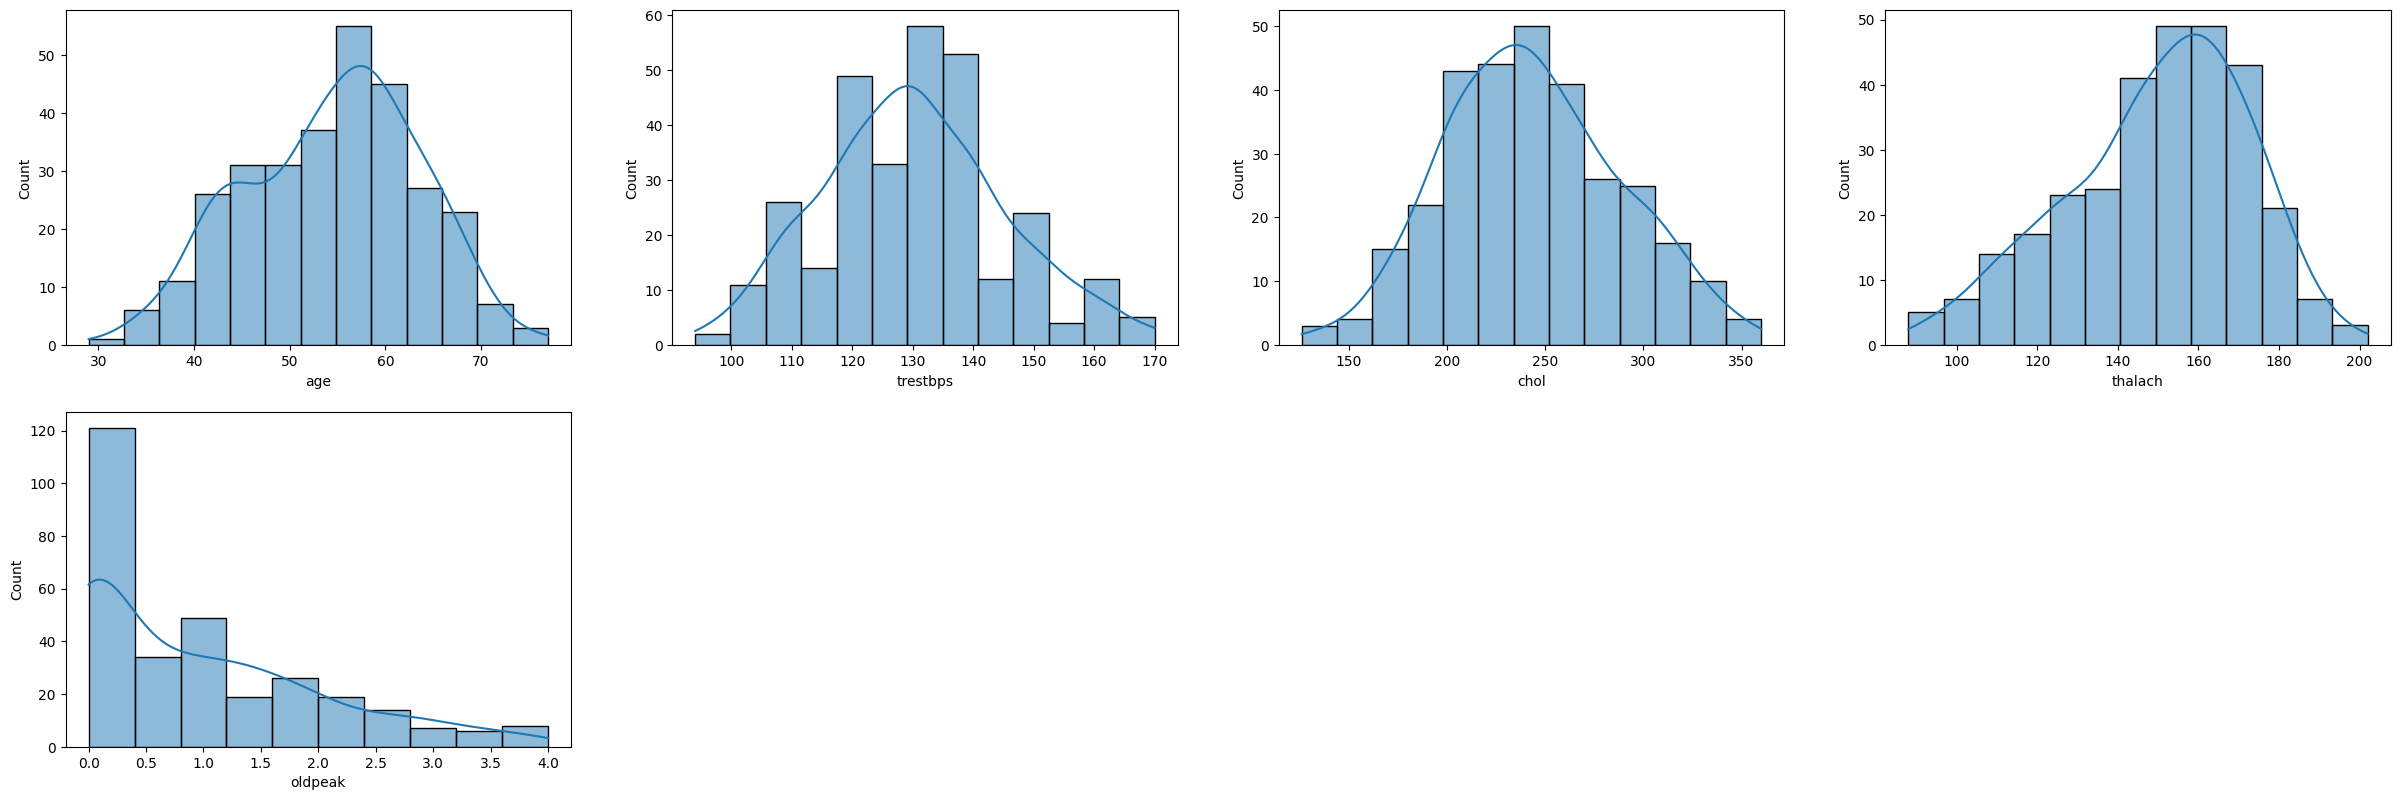

In [12]:
data_1.info()
import matplotlib.pyplot as plt
import seaborn as sns
data_1['age'] = data_1['age'].astype('float')
data_1['ca'] = data_1['ca'].astype('object')
A = data_1.select_dtypes('int')
for i in A:
    data_1[i] = data_1[i].astype('int')
plt.figure(figsize=(30, 20))
for i , col in enumerate(data_1.select_dtypes('float'),1):#continus variable distribution
    plt.subplot(4,4,i)
    histplot = sns.histplot(data_1[col],kde=True)


**Continous Distribution**

age ,trestbps ,chol ,thalach have normal distribution .


1
4 5


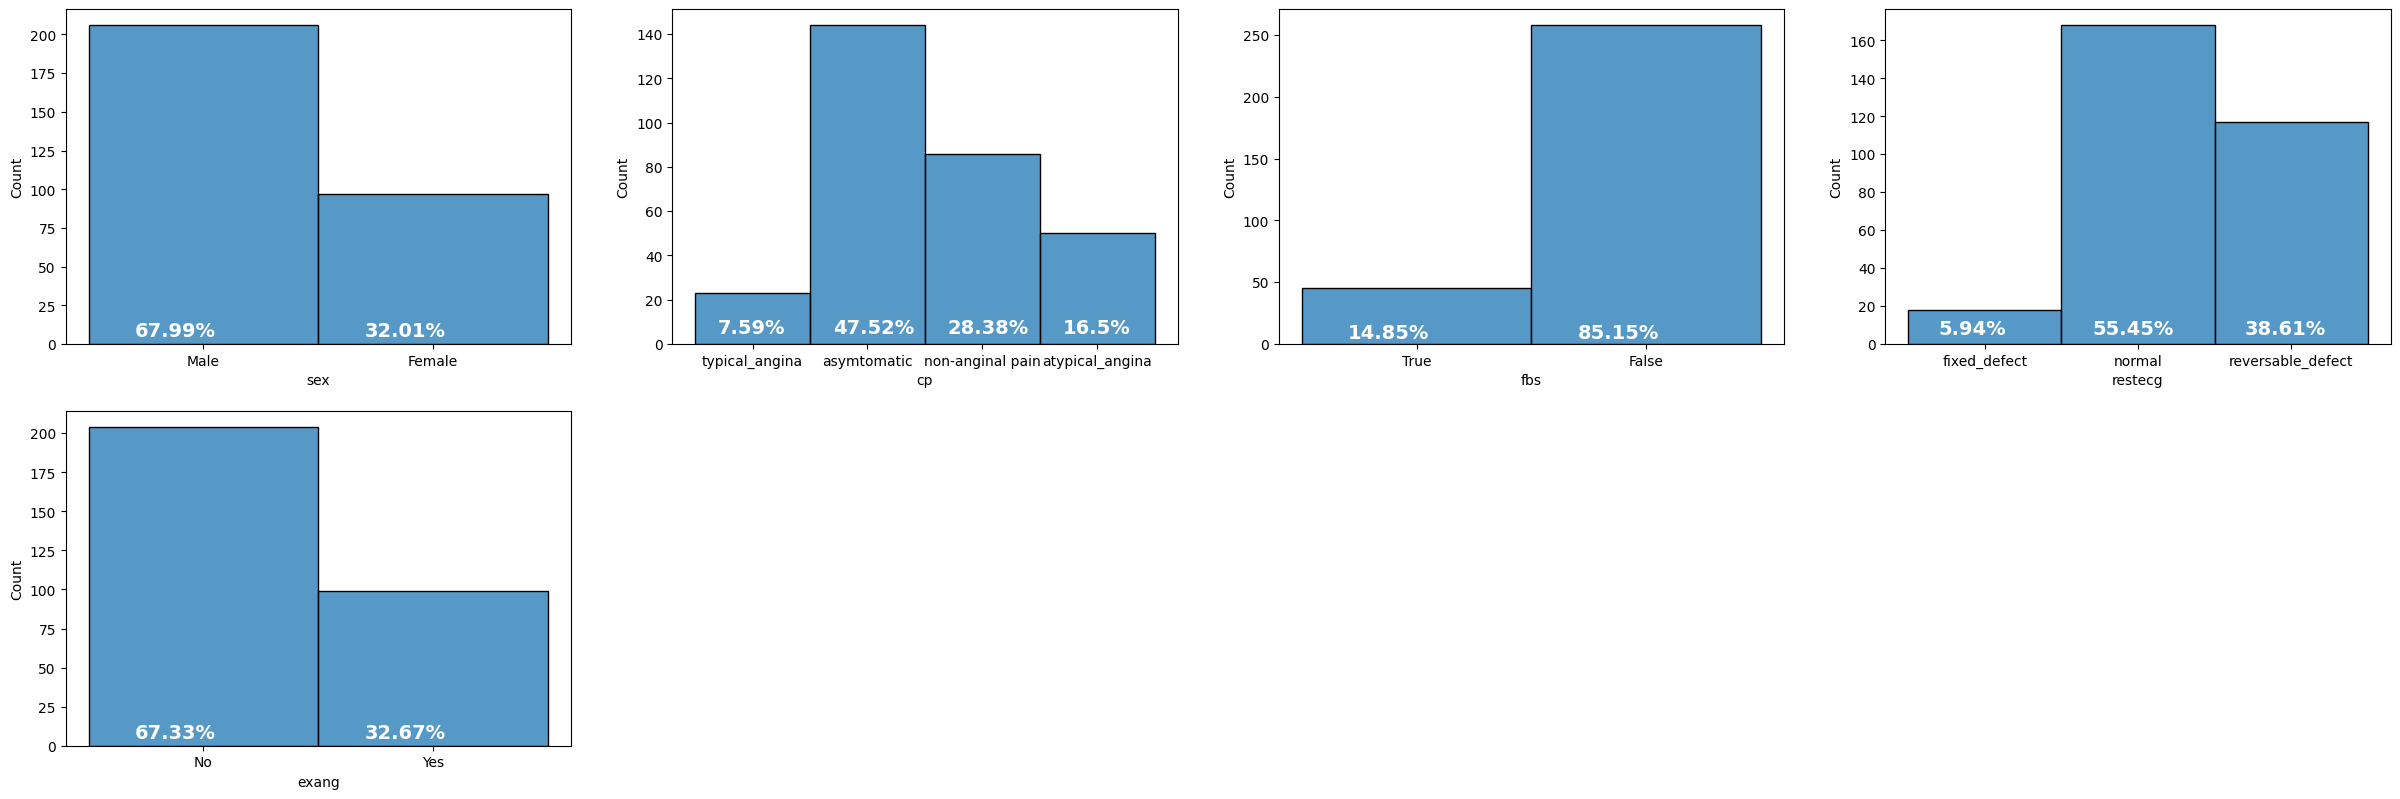

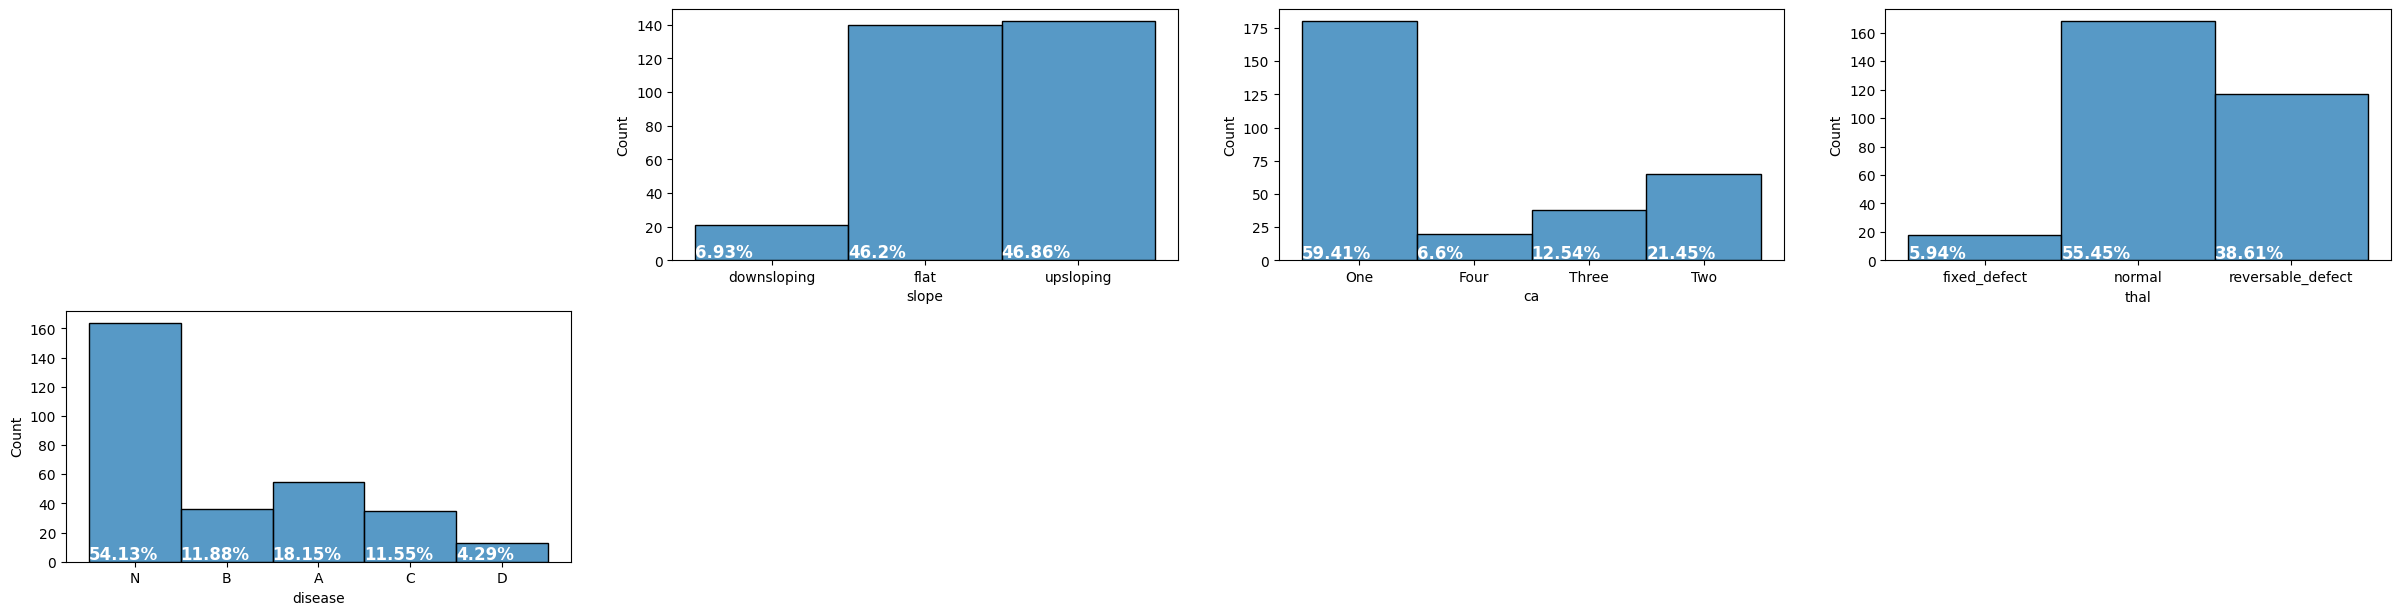

In [13]:
object_columns = data_1.select_dtypes(include='object').columns
a = len(object_columns)
b = 0
print(a % 2)
if a % 2 != 0:
    a = a//2
    b = a + 1
else : 
    a = a//2 
    b = a 
print(a,b)
plt.figure(figsize=(30, 20))
for i , col in enumerate(data_1.select_dtypes('object'),1):#continus variable distribution
    if i > a + 1  :
        continue
    plt.subplot(4,4,i)
    histplot = sns.histplot(data_1[col])
    total = 0
    for i in histplot.patches:
        total = total + i.get_height()
    for i in histplot.patches:
        histplot.text(i.get_x()+.2,i.get_y()+5,str(round((i.get_height()/total)*100, 2))+'%', fontsize=14,color='white', weight = 'bold')
plt.show()
plt.figure(figsize = (30, 15))
for i , col in enumerate(data_1.select_dtypes('object'),1):#continus variable distribution
    if i < b + 1 :
        continue
    plt.subplot(4,4,i)
    histplot = sns.histplot(data_1[col])
    total = 0
    for i in histplot.patches:
        total = total + i.get_height()
    for i in histplot.patches:
        histplot.text(i.get_x(),i.get_y()+5,str(round((i.get_height()/total)*100, 2))+'%', fontsize=12,color='white', weight = 'bold',va='center')
plt.show()


<Axes: >

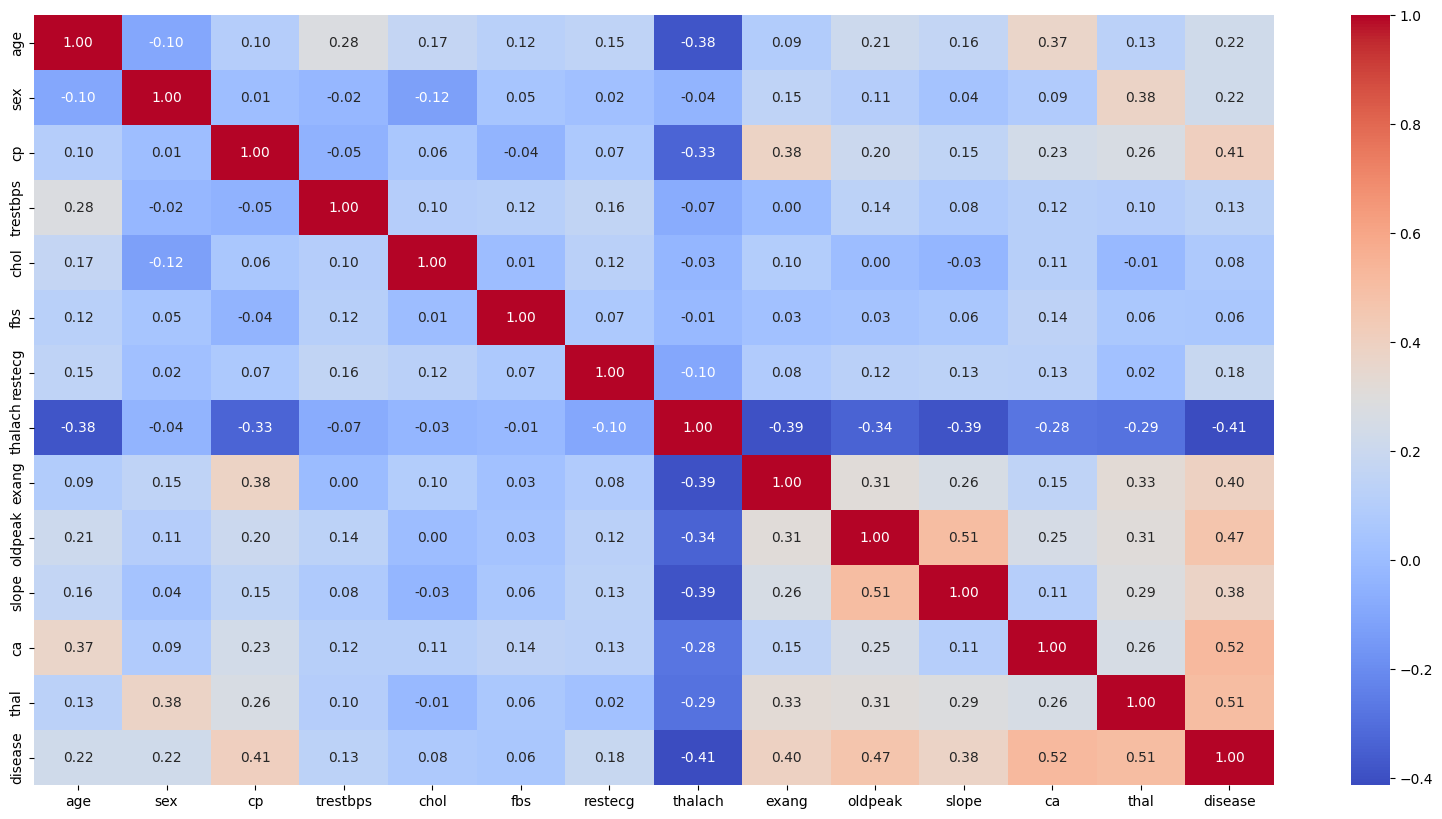

In [14]:
plt.figure(figsize=(20,10))
sns.heatmap(data_2.corr(), annot=True,cmap='coolwarm',fmt='.2f')

#### Data Relations

Because we have 14 columns , this means if we want show relation between at least 2 of these we will have 13 for each ,so we only show relations between the ones that have correlations above or near 0.30 or -.30 .


**age** 

age has worth looking to corr with below variables : 
* thalach 
* ca 
* disease

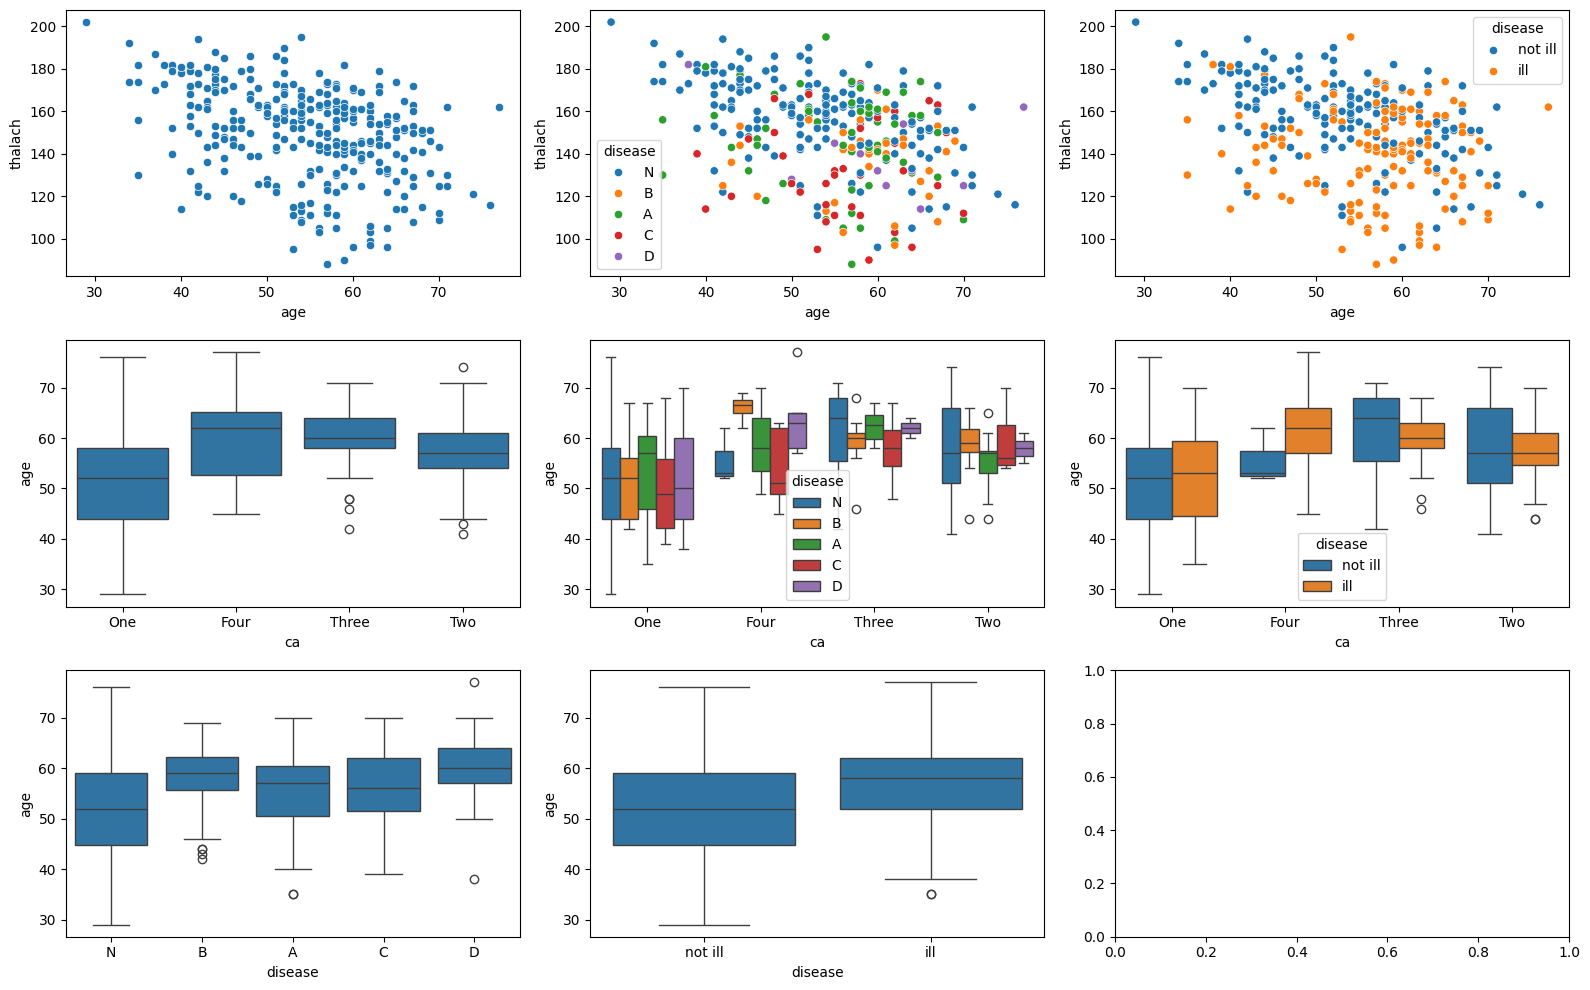

In [15]:
Valid_corrlist = ['ca','thalach']
fig , ax = plt.subplots(nrows= 3 , ncols=3 , figsize = (16,10))
sns.scatterplot(x='age',y='thalach',data=data_1,ax=ax[0,0])
sns.scatterplot(x='age',y='thalach',hue='disease',data=data_1,ax=ax[0,1])
a = list(data_1['disease'].unique())
a.remove('N')
data_changed = data_1['disease'].apply(lambda x: 'ill' if x in a else 'not ill')
sns.scatterplot(x='age',y='thalach',hue=data_changed,data=data_1,ax=ax[0,2])
sns.boxplot(x='ca',y='age',data=data_1,ax=ax[1,0])
sns.boxplot(x='ca',y='age',hue='disease',data=data_1,ax=ax[1,1])
sns.boxplot(x='ca',y='age',hue=data_changed,data=data_1,ax=ax[1,2])
sns.boxplot(x='disease',y='age',data=data_1,ax=ax[2,0])
sns.boxplot(x= data_changed,y='age',data=data_1,ax=ax[2,1])

plt.tight_layout()


From the scaterplot ,we can see that most of ill people mostly have highest heart rate lower then 160 and only few has more .
From relation between age and closed vessels we can see that most poeple that have closed vessels are over 55 .
and when we check for illness , we see that most ill people have no vessels closed .
most ill people are older people(above 53).

**Sex**
relations worth looking 
* thal
* disease 
* age 

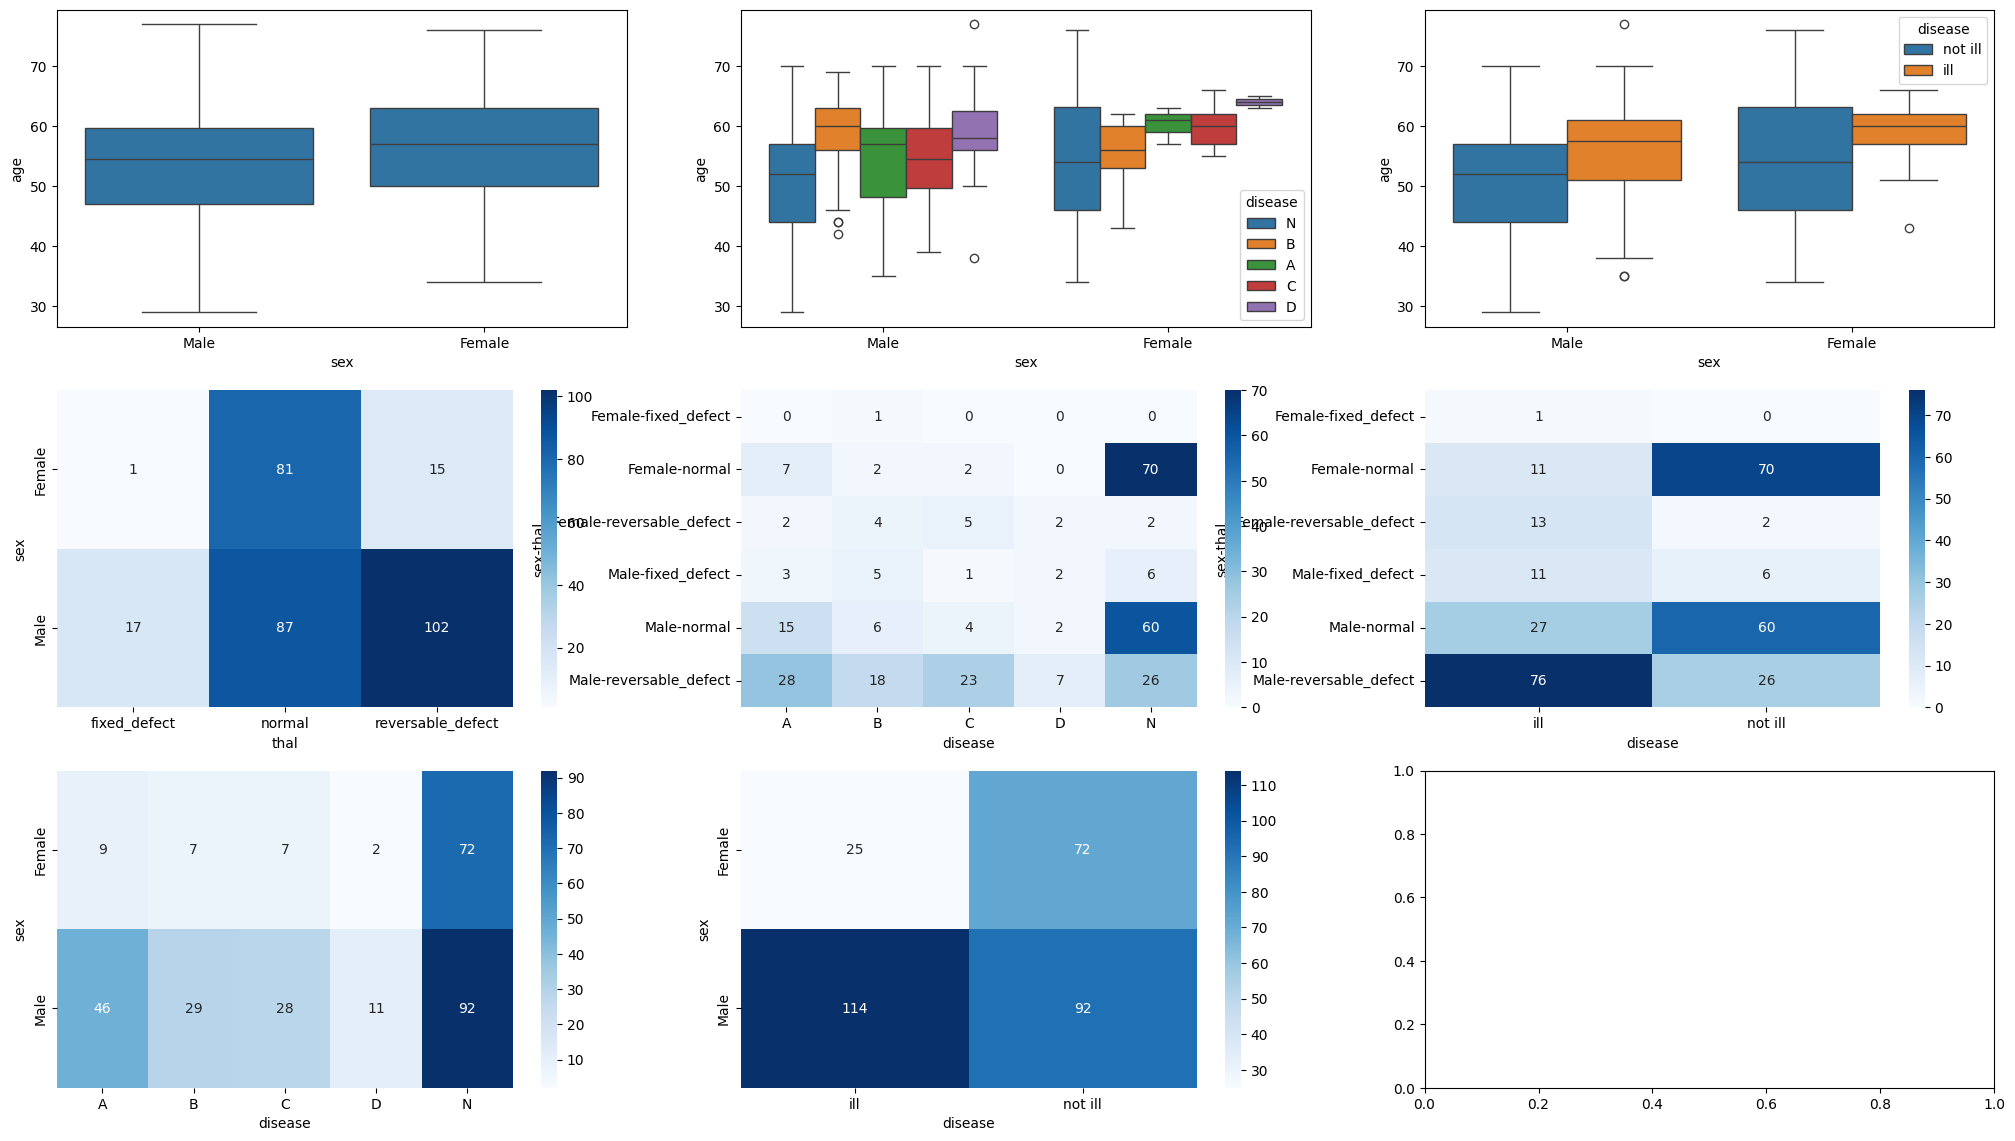

In [16]:
Valid_corrlist = ['thal','age']
fig , ax = plt.subplots(nrows= 3 , ncols=3 , figsize = (25,14))
sns.boxplot(x='sex',y='age',data=data_1,ax=ax[0,0])
sns.boxplot(x='sex',y='age',hue='disease',data=data_1,ax=ax[0,1])
sns.boxplot(x='sex',y='age',hue=data_changed,data=data_1,ax=ax[0,2])
axe = sns.heatmap(pd.crosstab(data_1['sex'] , data_1['thal']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,0])
axe = sns.heatmap(pd.crosstab([data_1['sex'] , data_1['thal']],data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,1])
axe = sns.heatmap(pd.crosstab([data_1['sex'] , data_1['thal']],data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,2])
axe = sns.heatmap(pd.crosstab(data_1['sex'],data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[2,0])
axe = sns.heatmap(pd.crosstab(data_1['sex'],data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[2,1])

Majority of women are older .
men are more likely to have illness base on plot sex ,age , hue = disease .


**CP**
relations worth looking 
* disease   
* exang 
* thalach 

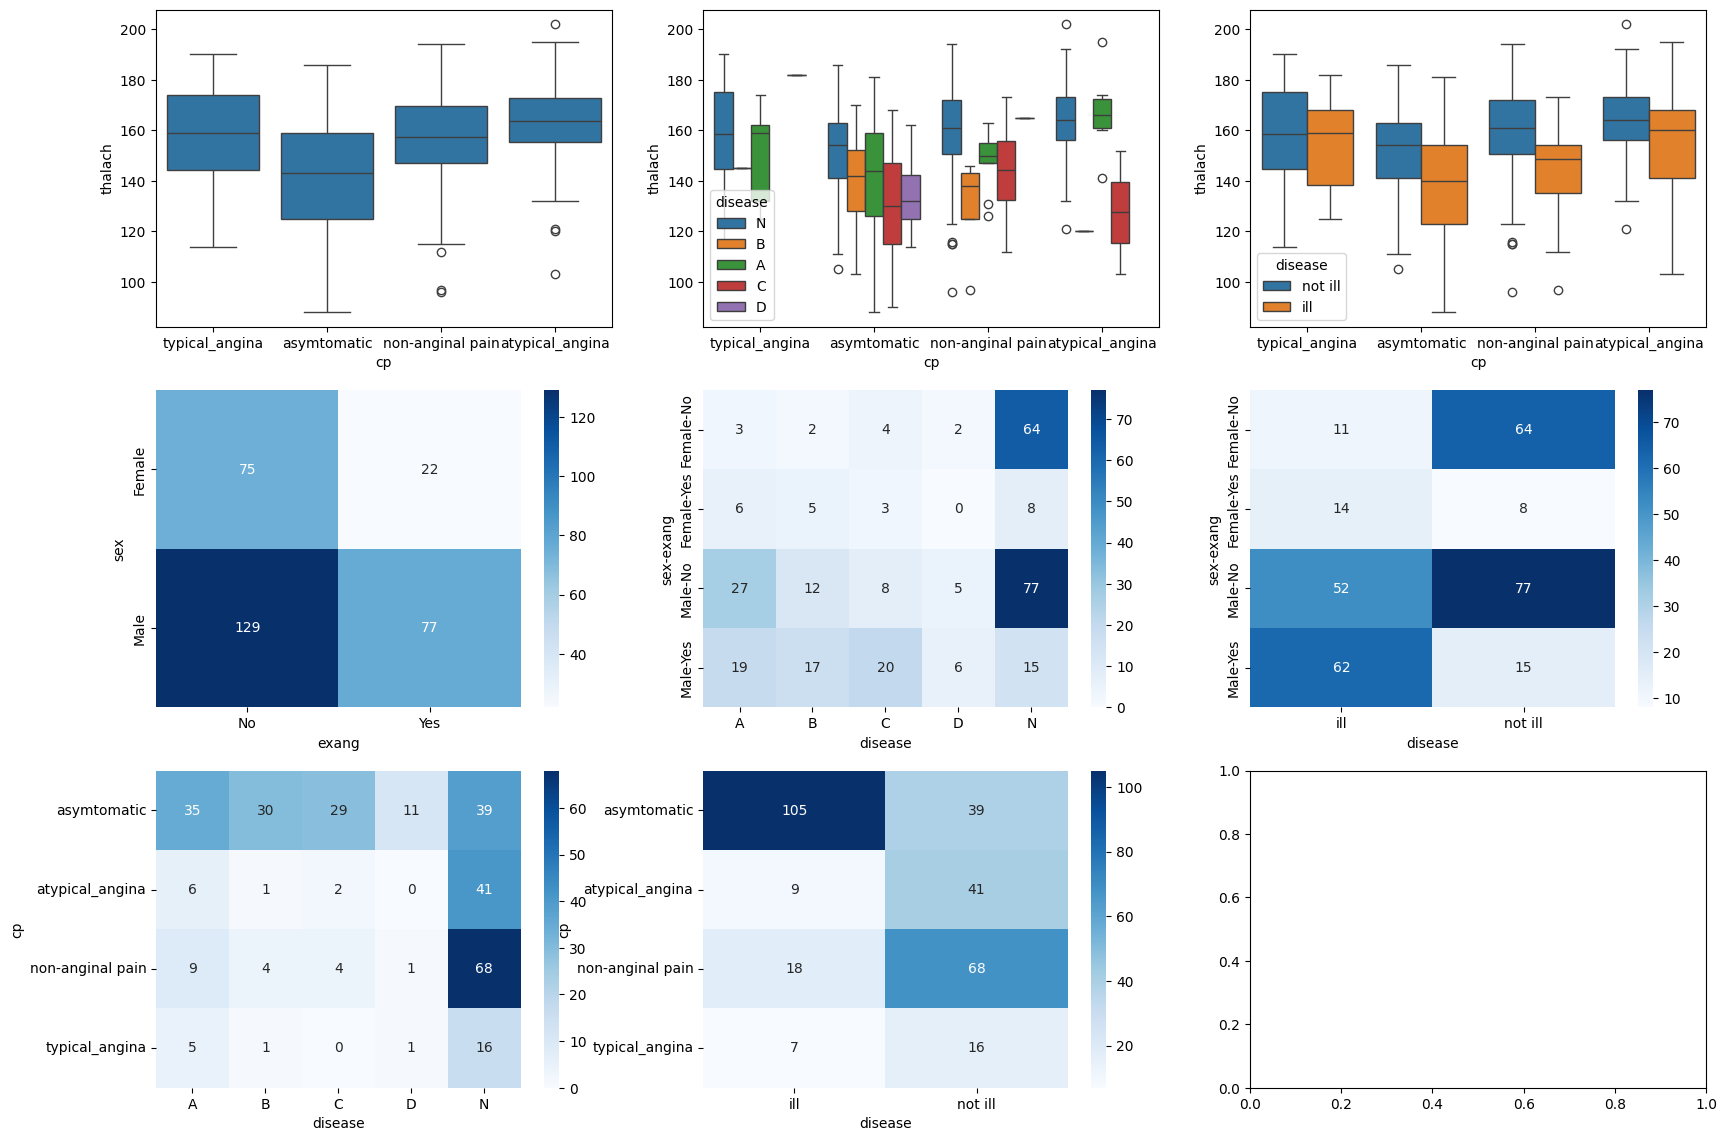

In [17]:
Valid_corrlist = ['exang','thalach']
fig , ax = plt.subplots(nrows= 3 , ncols=3 , figsize = (20,14))
sns.boxplot(x='cp',y='thalach',data=data_1,ax=ax[0,0])
sns.boxplot(x='cp',y='thalach',hue='disease',data=data_1,ax=ax[0,1])
sns.boxplot(x='cp',y='thalach',hue=data_changed,data=data_1,ax=ax[0,2])
sns.heatmap(pd.crosstab(data_1['sex'] , data_1['exang']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,0])
sns.heatmap(pd.crosstab([data_1['sex'] , data_1['exang']],data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,1])
sns.heatmap(pd.crosstab([data_1['sex'] , data_1['exang']],data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,2])
sns.heatmap(pd.crosstab(data_1['cp'],data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[2,0])
sns.heatmap(pd.crosstab(data_1['cp'],data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[2,1])
plt.show()

most ill people spicially class B,C,D are having the asymtomatic chest pain .
most ill people have lower max heart rate . 
most not ill women have exang no .
highest chest pain for ill poeple is asymtomatic pain .


**trestbps**
relations worth looking 
* disease   
* age 


<Axes: xlabel='disease', ylabel='trestbps'>

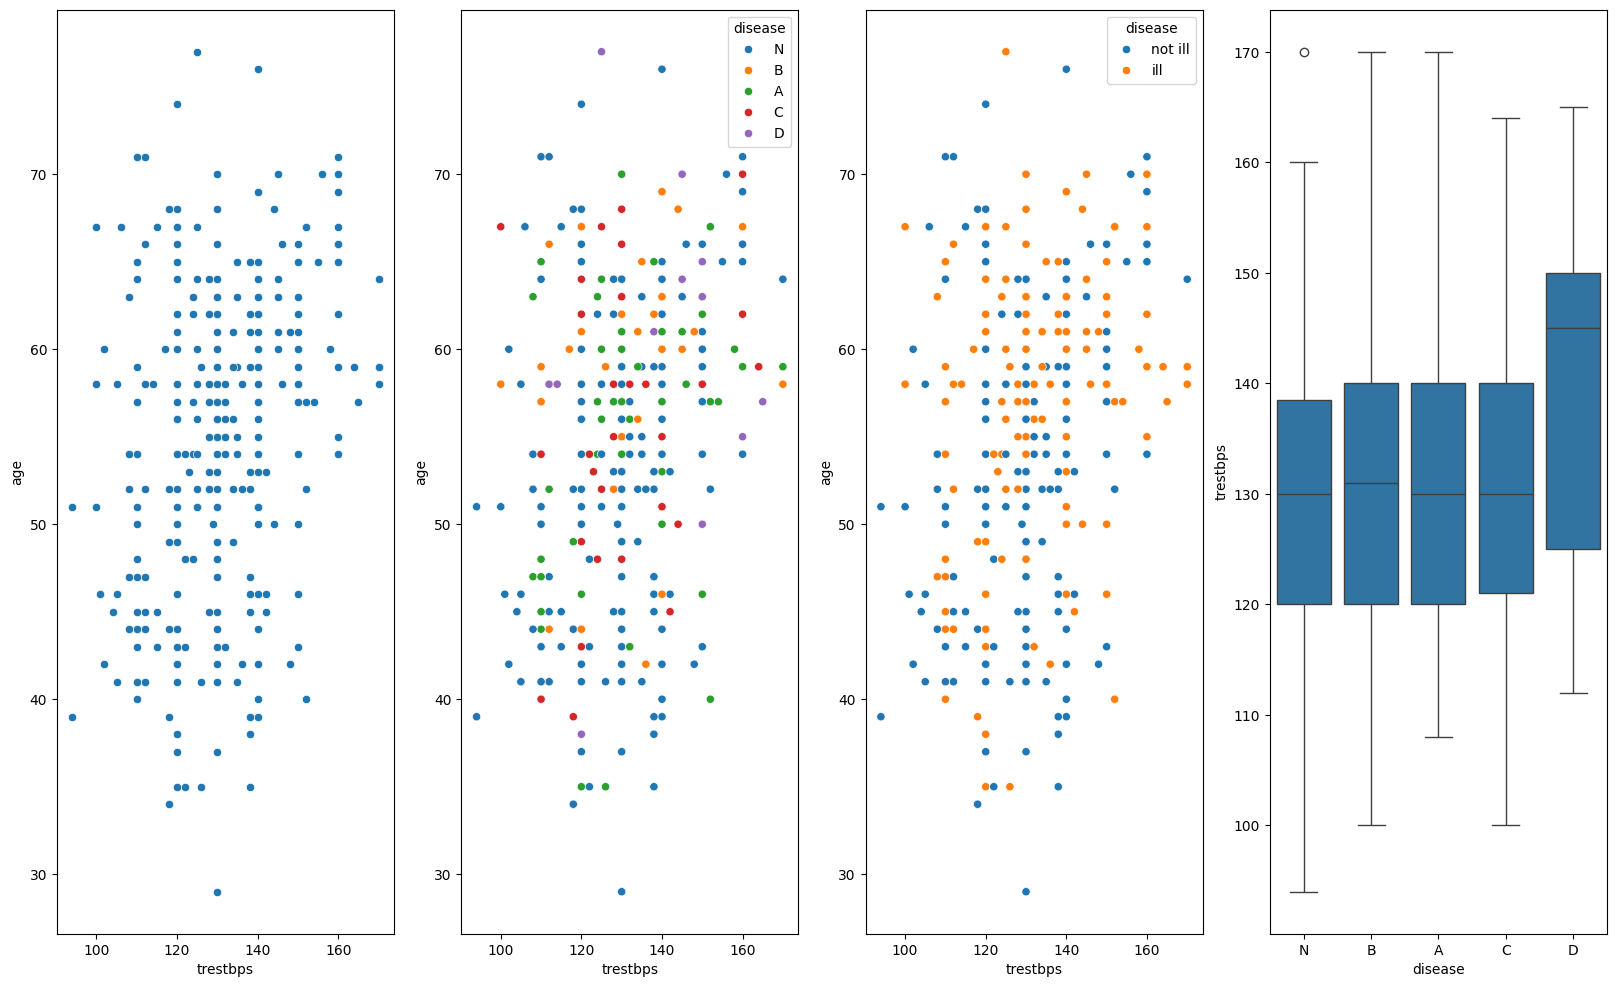

In [18]:
Valid_corrlist = ['age']
fig , ax = plt.subplots(nrows= 1 , ncols=4 , figsize = (20,12))
sns.scatterplot(x='trestbps',y='age',data=data_1,ax=ax[0])
sns.scatterplot(x='trestbps',y='age',hue='disease',data=data_1,ax=ax[1])
sns.scatterplot(x='trestbps',y='age',hue=data_changed,data=data_1,ax=ax[2])
sns.boxplot(x='disease',y='trestbps',data=data_1,ax=ax[3])

class D disease has higher blood presure rate .

**chol**
worth relations 
* disease

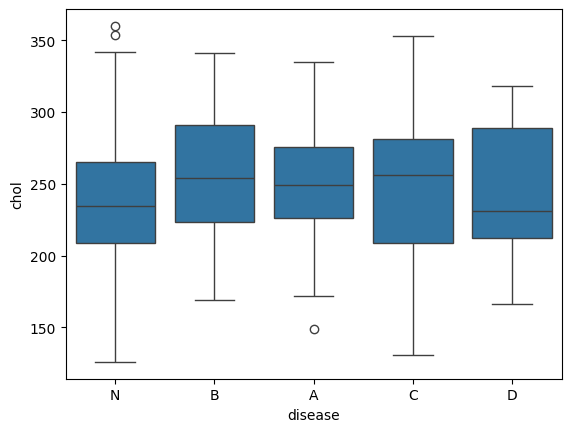

In [19]:
sns.boxplot(x='disease',y='chol',data=data_1)
plt.show()



**fbs**
worth relations 
* disease
* age

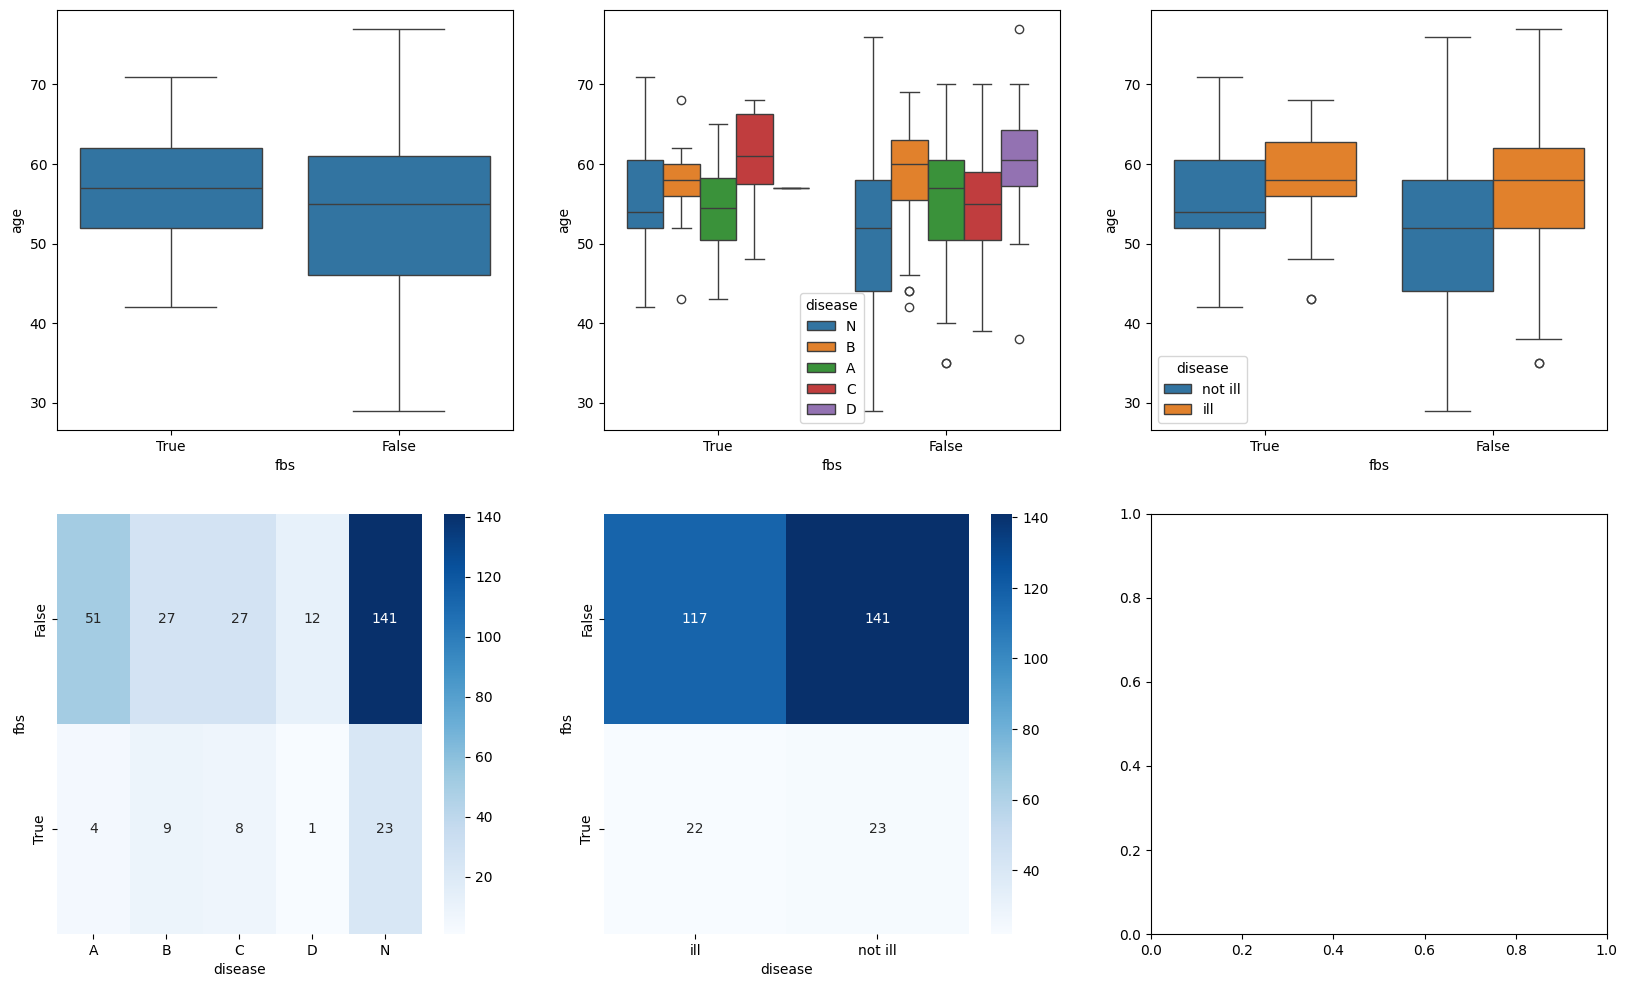

In [20]:
Valid_corrlist = ['age']
fig , ax = plt.subplots(nrows= 2 , ncols=3 , figsize = (20,12))
sns.boxplot(x='fbs',y='age',data=data_1,ax=ax[0,0])
sns.boxplot(x='fbs',y='age',hue='disease',data=data_1,ax=ax[0,1])
sns.boxplot(x='fbs',y='age',hue=data_changed,data=data_1,ax=ax[0,2])
axe = sns.heatmap(pd.crosstab(data_1['fbs'] , data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,0])
axe = sns.heatmap(pd.crosstab(data_1['fbs'] , data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,1])

plt.show()

illness and disease has opposite connection . most ill people dont have diabetes.
most people that are ill and have diabetes are old .
 

**restecg**
worth looking 
* age

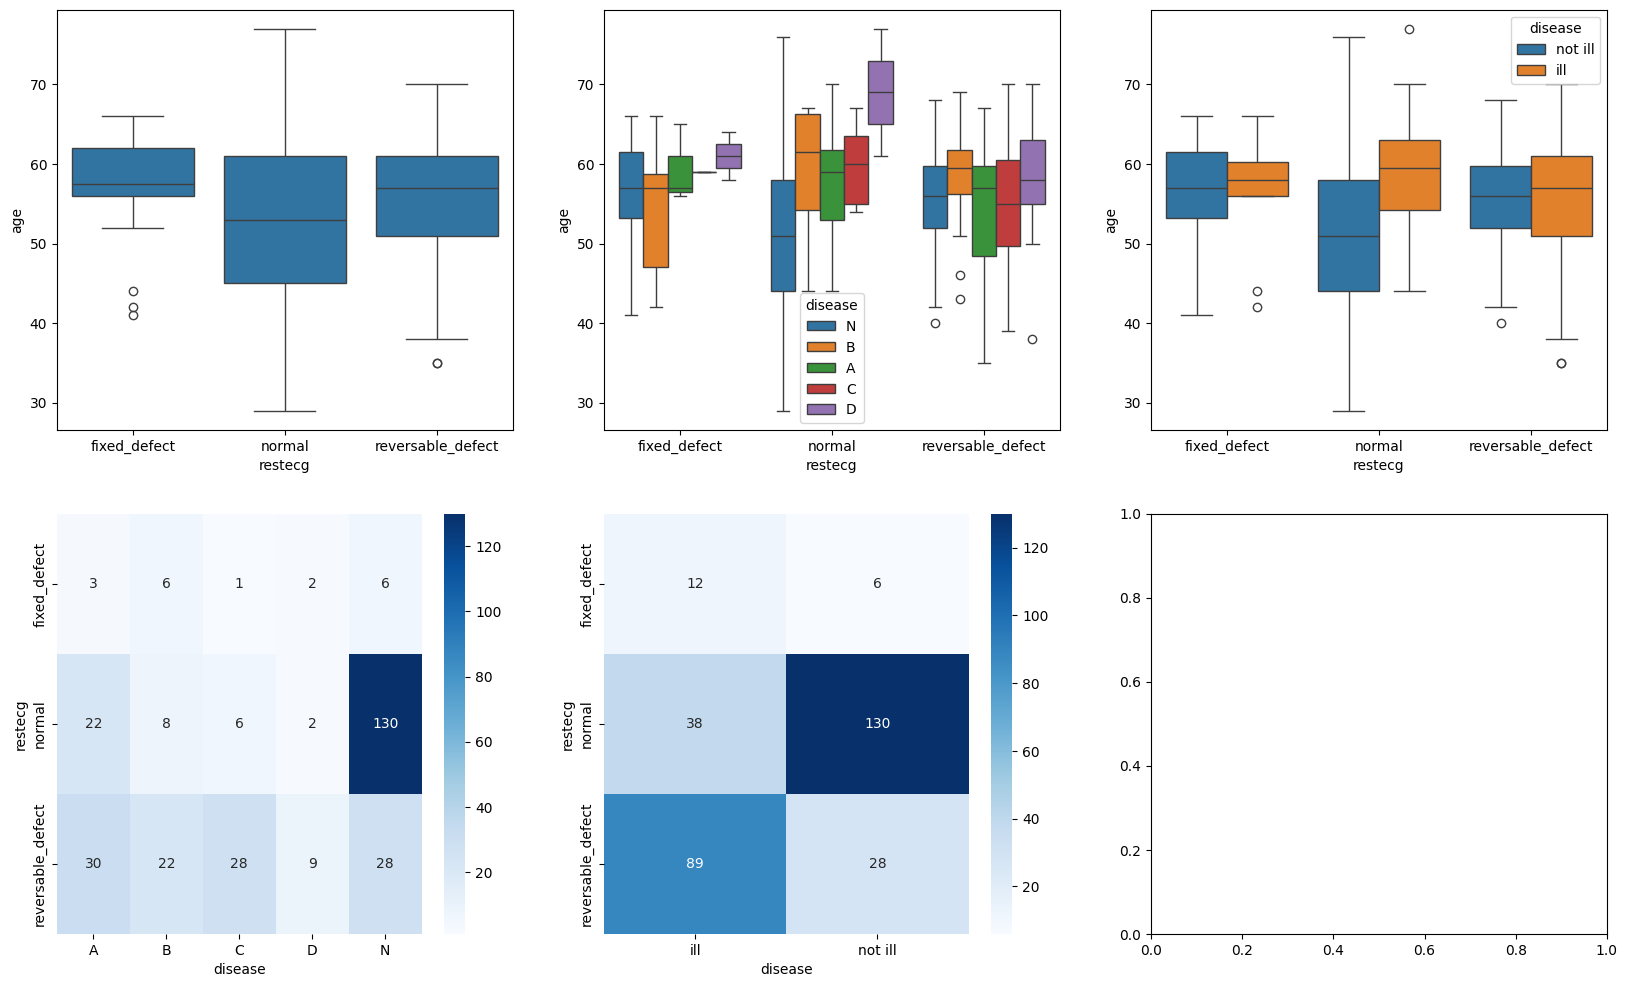

In [21]:
Valid_corrlist = ['age']
fig , ax = plt.subplots(nrows= 2 , ncols=3 , figsize = (20,12))
sns.boxplot(x='restecg',y='age',data=data_1,ax=ax[0,0])
sns.boxplot(x='restecg',y='age',hue='disease',data=data_1,ax=ax[0,1])
sns.boxplot(x='restecg',y='age',hue=data_changed,data=data_1,ax=ax[0,2])
axe = sns.heatmap(pd.crosstab(data_1['restecg'] , data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,0])
axe = sns.heatmap(pd.crosstab(data_1['restecg'] , data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,1])

plt.show()

class A,C,D are older and have normal and reversable defect . 
most class B that are older have fixed defect .


**thalach**
relations worth looking 
* disease
* slope 
* exang 

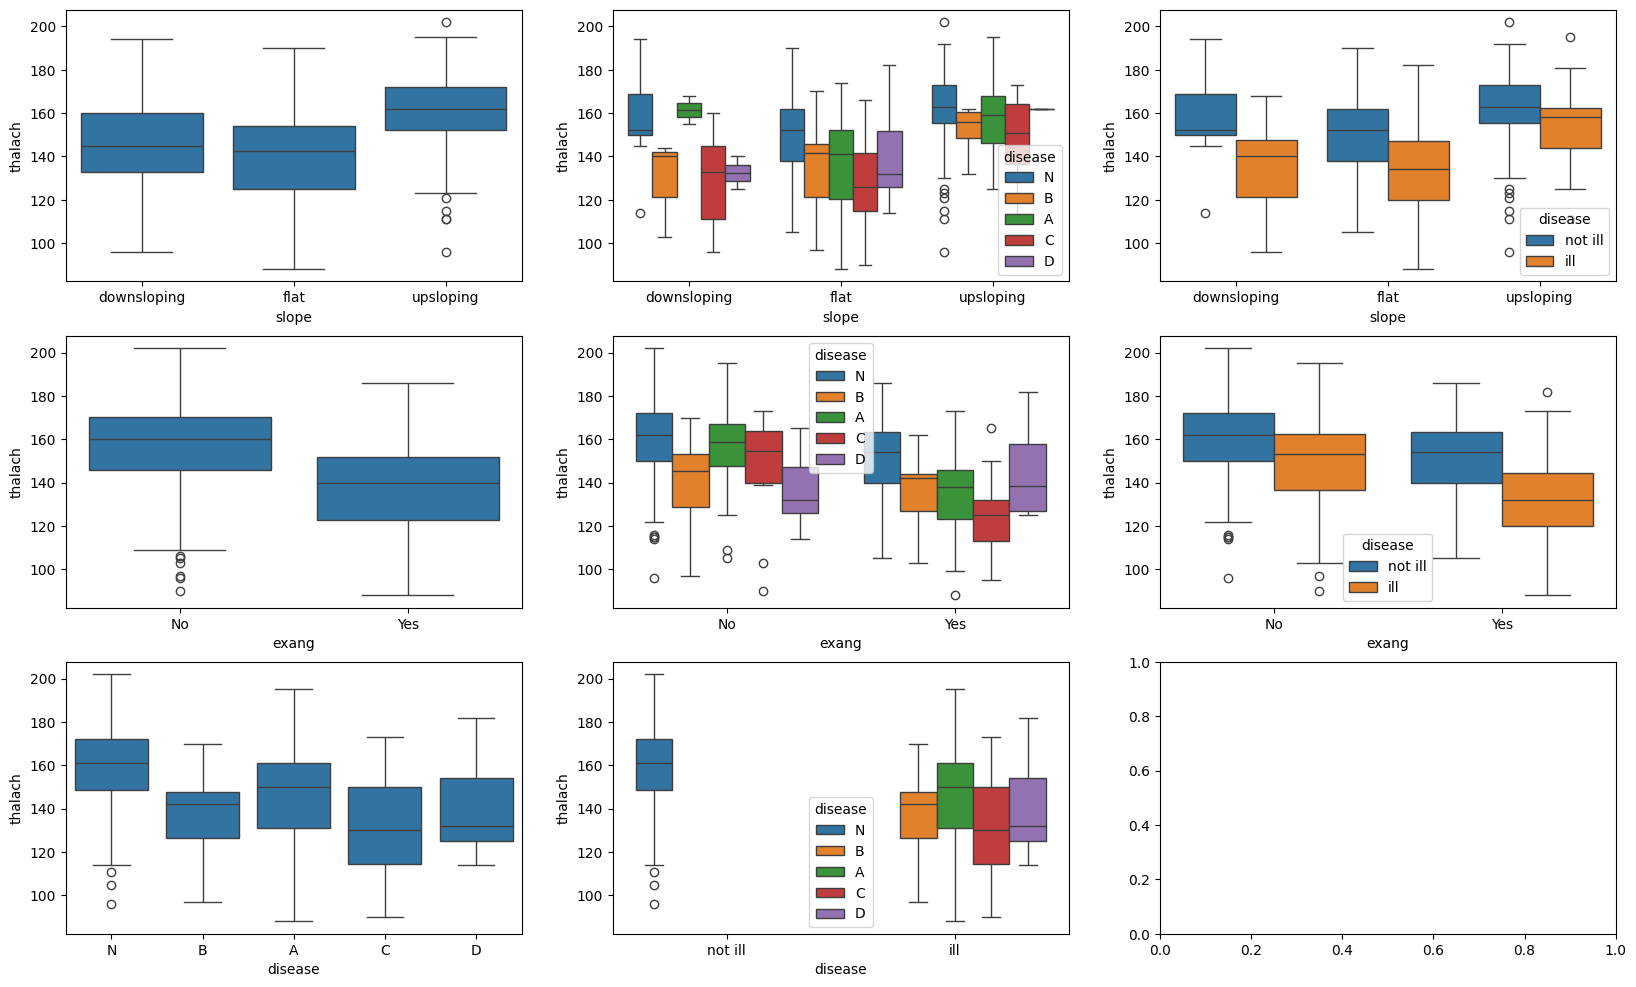

In [22]:
Valid_corrlist = ['exang','thalach']
fig , ax = plt.subplots(nrows=3 , ncols=3 , figsize = (20,12))
sns.boxplot(x='slope',y='thalach',data=data_1,ax=ax[0,0])
sns.boxplot(x='slope',y='thalach',hue='disease',data=data_1,ax=ax[0,1])
sns.boxplot(x='slope',y='thalach',hue=data_changed,data=data_1,ax=ax[0,2])
sns.boxplot(x='exang',y='thalach',data=data_1,ax=ax[1,0])
sns.boxplot(x='exang',y='thalach',hue='disease',data=data_1,ax=ax[1,1])
sns.boxplot(x='exang',y='thalach',hue=data_changed,data=data_1,ax=ax[1,2])
sns.boxplot(x='disease',y='thalach',data=data_1,ax=ax[2,0])
sns.boxplot(x= data_changed,y='thalach',hue='disease',data=data_1,ax=ax[2,1])
plt.show()


upsloping has higher max heart rate . most ill people class D have flat slope .
other classes  are mostly have flat slope and upsloping .
most ill people with exang yes has lower max heart rate .



**exang**
worth looking 
* disease
* thal

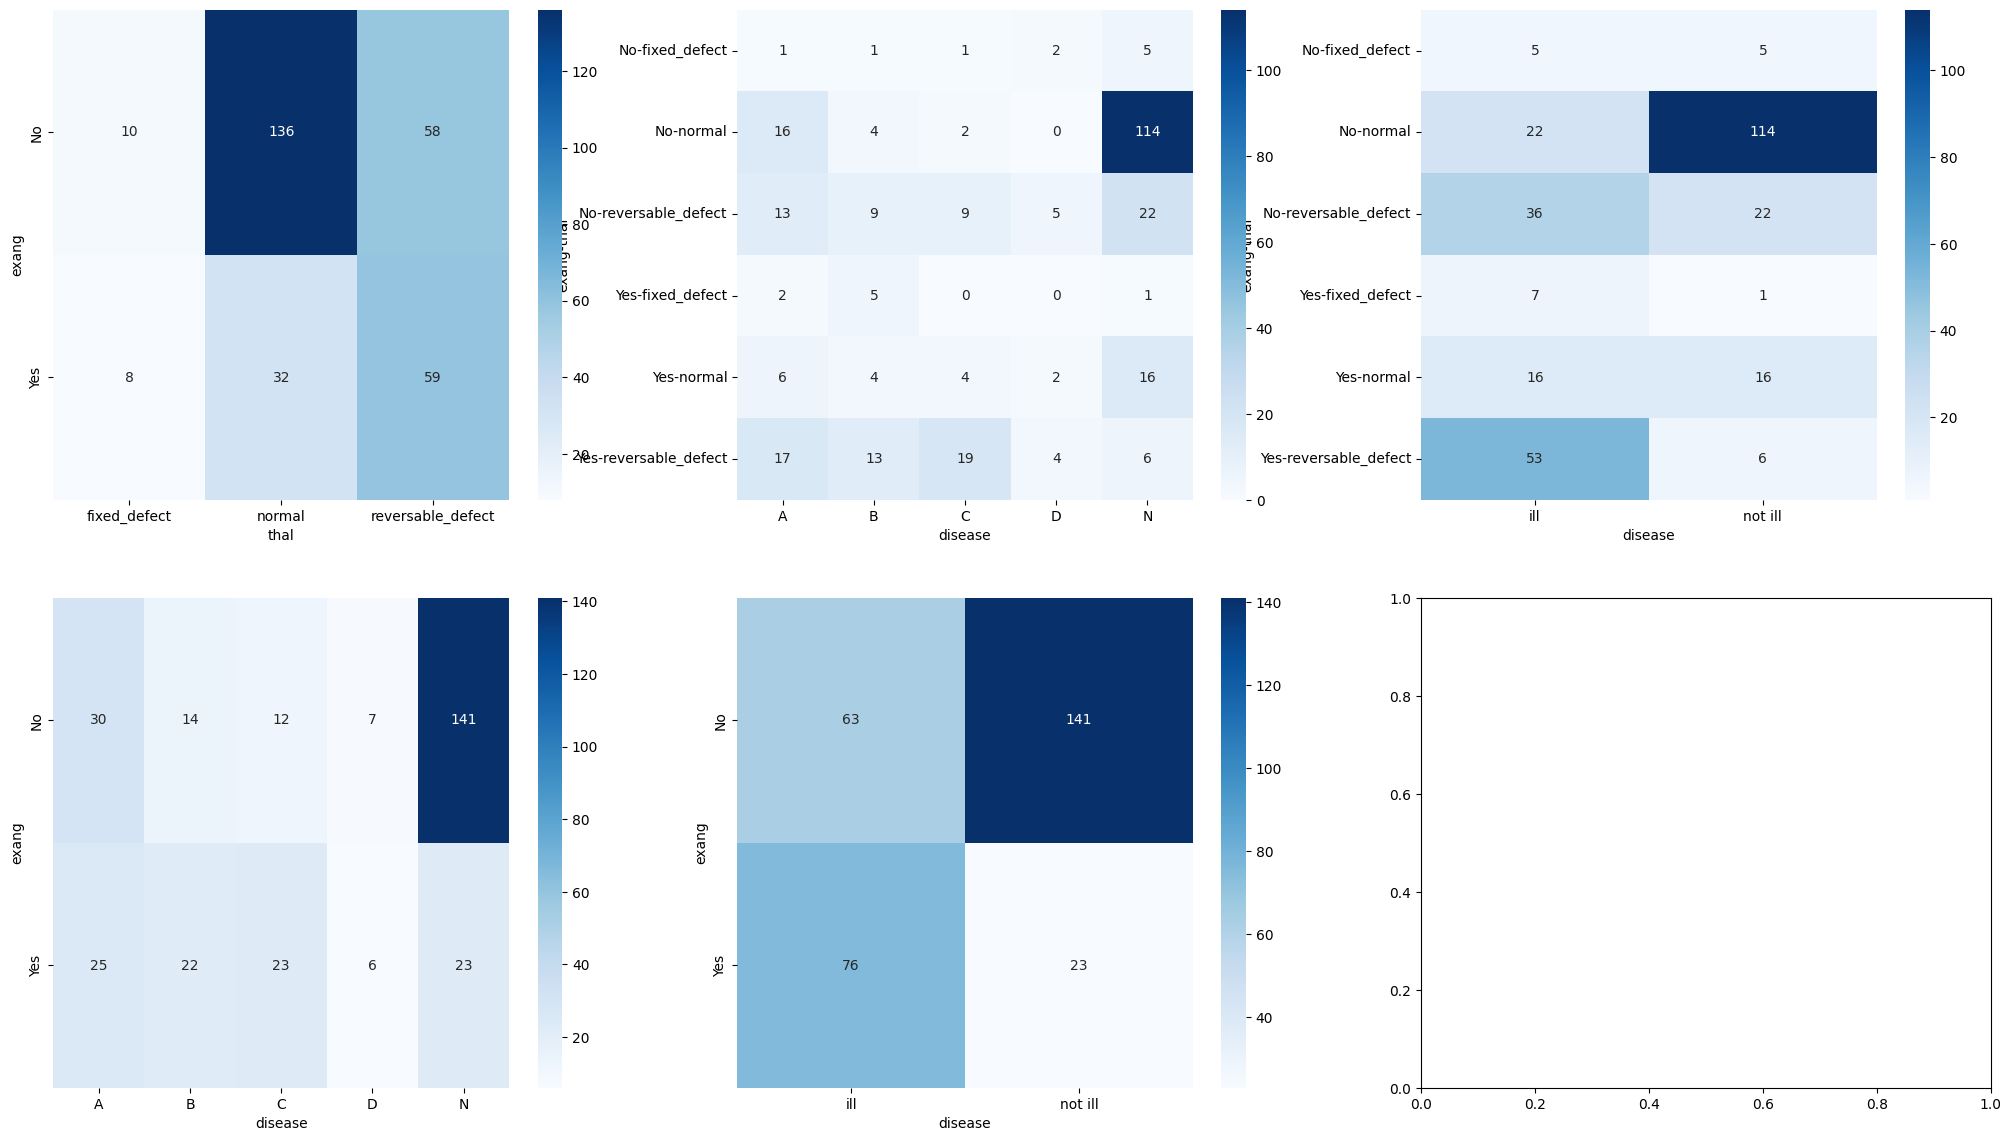

In [23]:
Valid_corrlist = ['thal']
fig , ax = plt.subplots(nrows= 2 , ncols=3 , figsize = (25,14))
sns.heatmap(pd.crosstab(data_1['exang'] , data_1['thal']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[0,0])
sns.heatmap(pd.crosstab([data_1['exang'] , data_1['thal']],data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[0,1])
sns.heatmap(pd.crosstab([data_1['exang'] , data_1['thal']],data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[0,2])
sns.heatmap(pd.crosstab(data_1['exang'] , data_1['disease']) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,0])
sns.heatmap(pd.crosstab(data_1['exang'] ,data_changed) , annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,1])
plt.show()

most not ill people have normal thal .
most ill people have yes reversable defect .



**oldpeak**
worth looking 
* disease
* slope

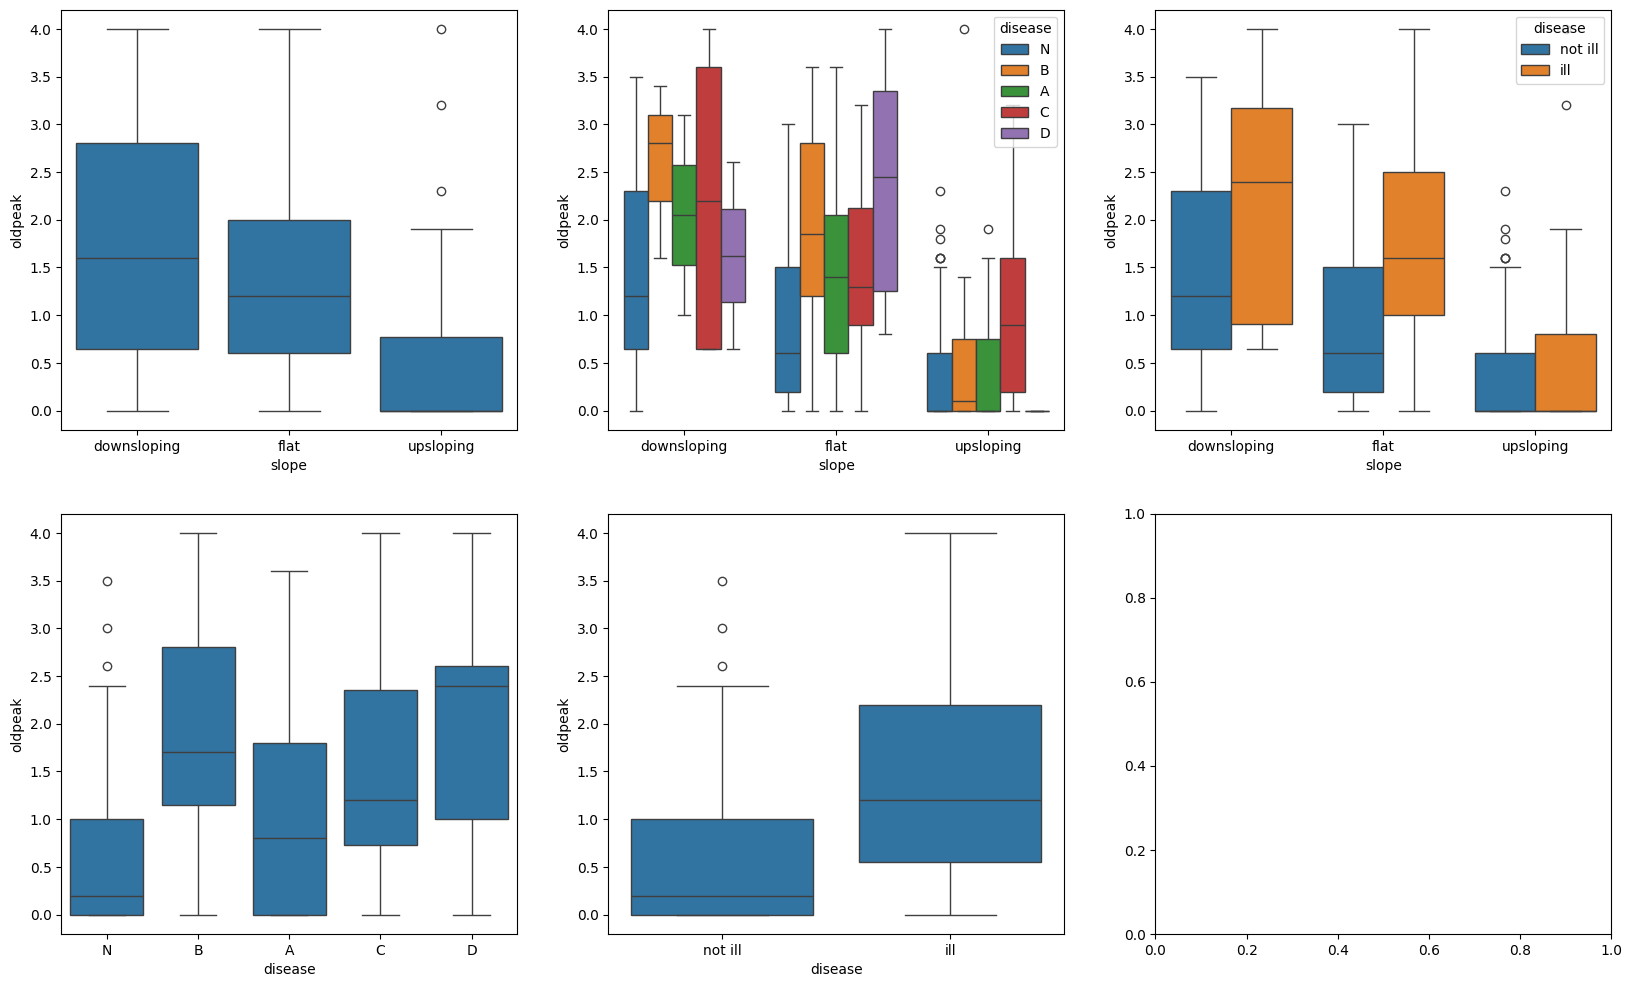

In [24]:
Valid_corrlist = ['slope']
fig , ax = plt.subplots(nrows= 2 , ncols=3 , figsize = (20,12))
sns.boxplot(x= 'slope',y='oldpeak',data=data_1,ax=ax[0,0])
sns.boxplot(x= 'slope',y='oldpeak',hue='disease' ,data=data_1,ax=ax[0,1])
sns.boxplot(x= 'slope',y='oldpeak',hue=data_changed,data=data_1,ax=ax[0,2])
sns.boxplot(x= 'disease',y='oldpeak',data=data_1,ax=ax[1,0])
sns.boxplot(x= data_changed,y='oldpeak',data=data_1,ax=ax[1,1])
plt.show()

downsloping and flat slope has oldpeak rate over 1 and upsloping has rate lower then 1 .
most ill people has oldpeak rate higher then 1 , and not ill have less then 1 .
 

**slope**
worth looking
* disease


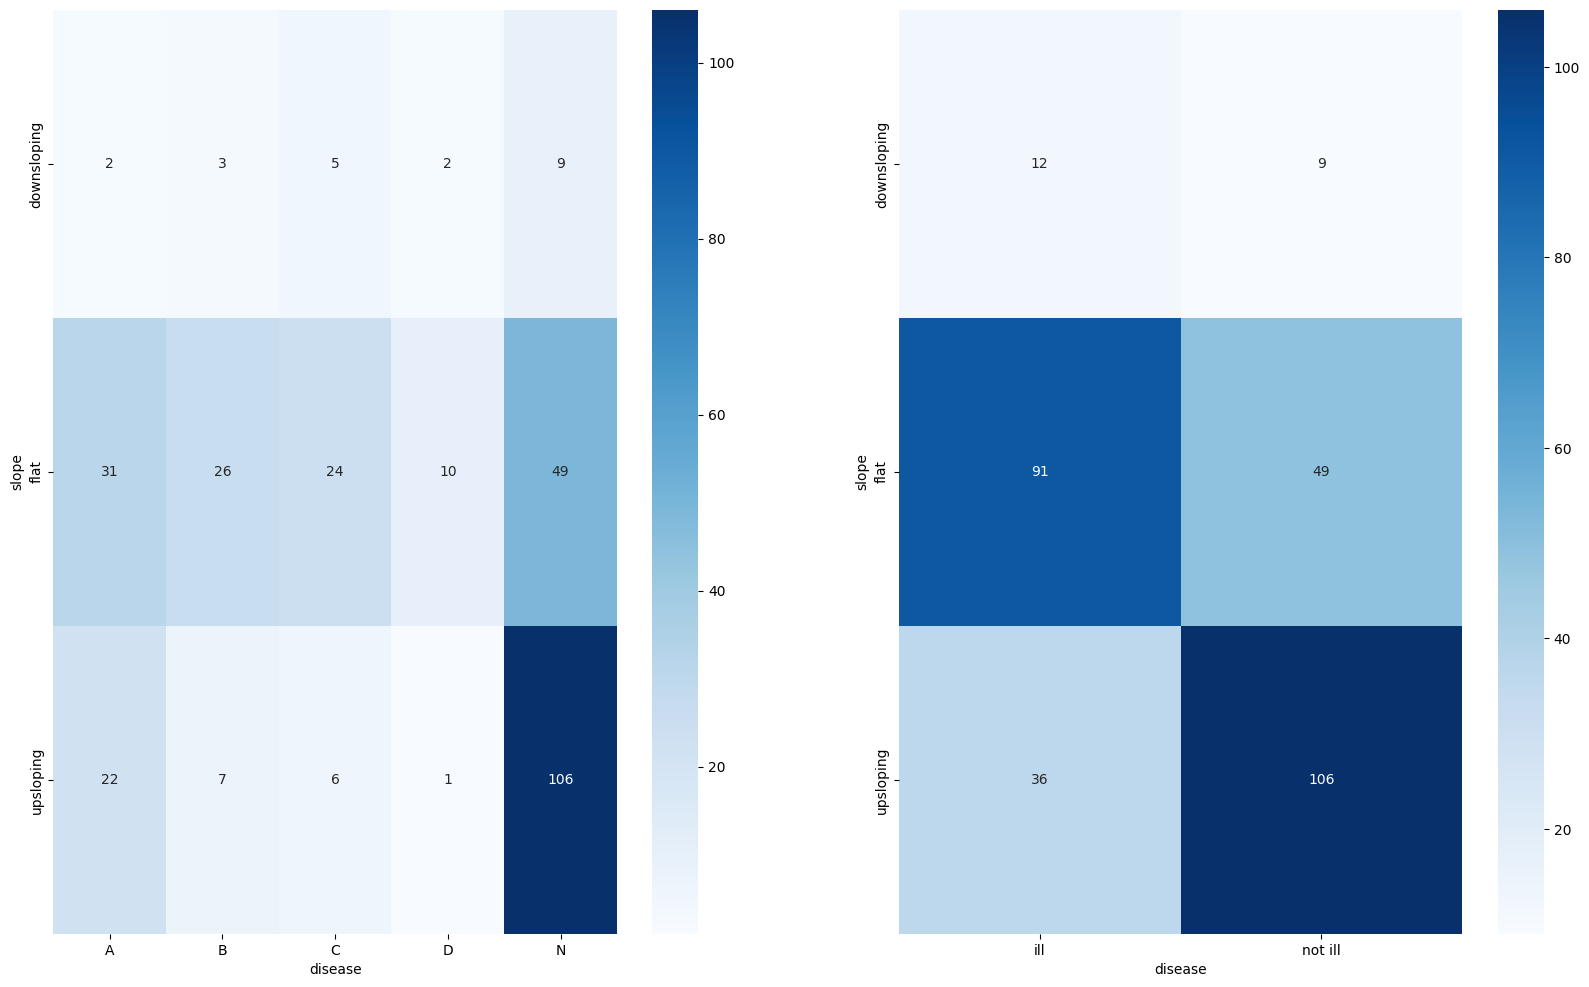

In [25]:
Valid_corrlist = ['disease']
fig , ax = plt.subplots(nrows= 1 , ncols=2 , figsize = (20,12))
sns.heatmap(pd.crosstab(data_1['slope'],data_1['disease']),annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[0])
sns.heatmap(pd.crosstab(data_1['slope'],data_changed),annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1])
plt.show()

most healthy people have upsloping  and flat slope .



**ca**
worth looking 
* disease

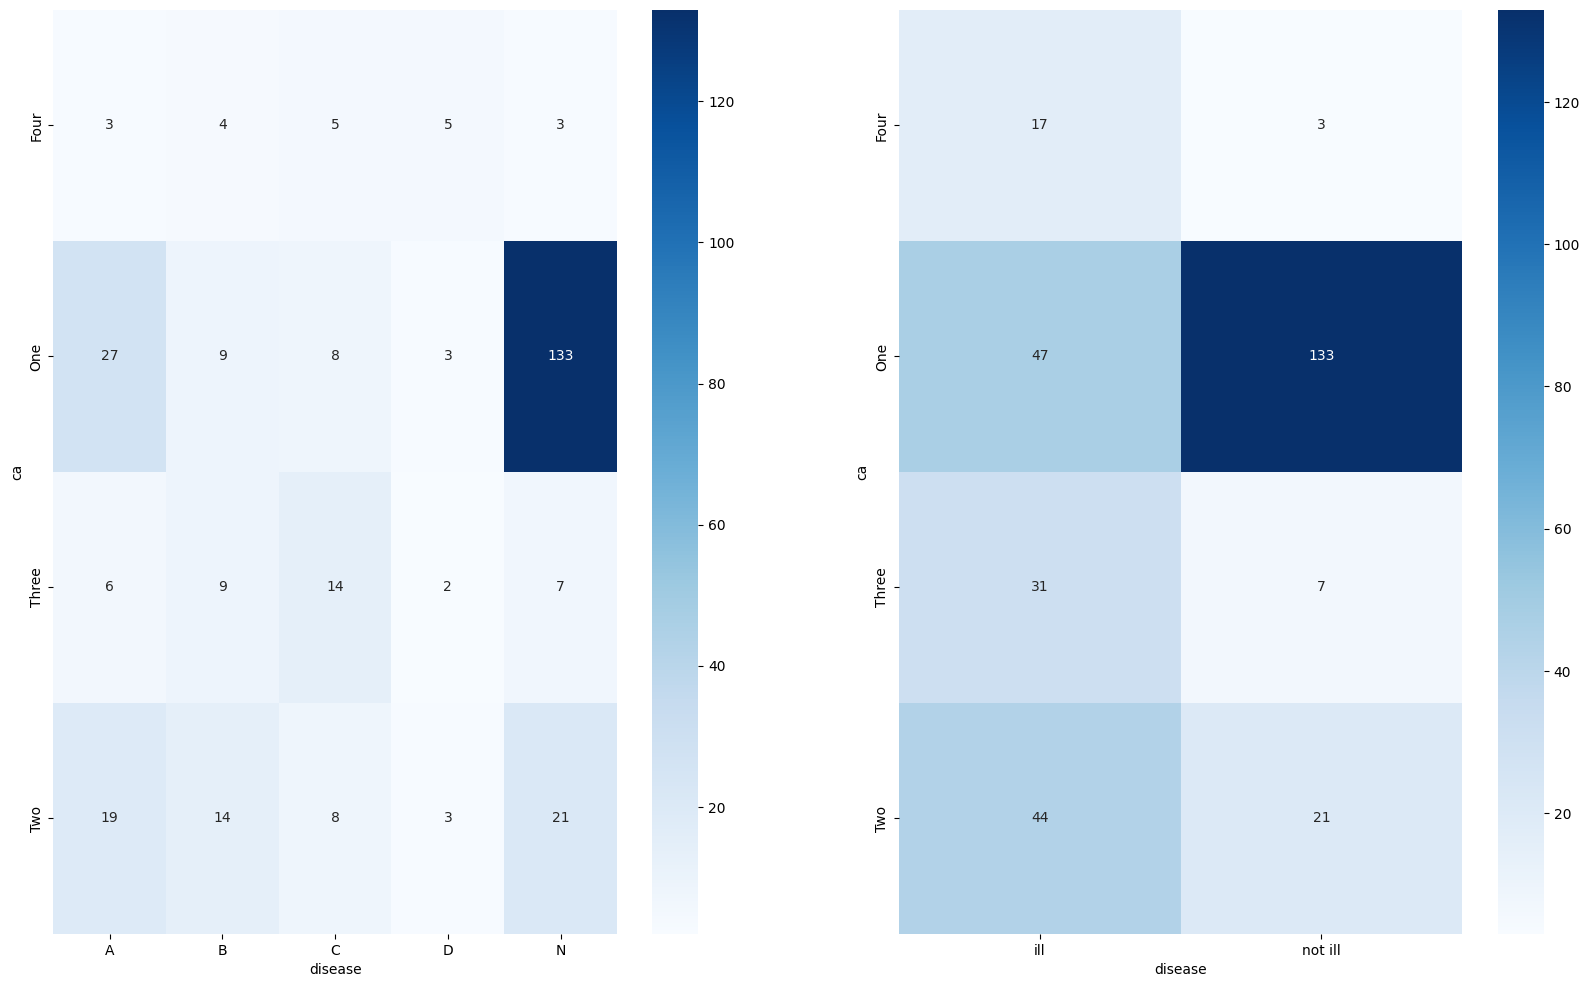

In [26]:
Valid_corrlist = ['disease']
fig , ax = plt.subplots(nrows= 1 , ncols=2 , figsize = (20,12))
sns.heatmap(pd.crosstab(data_1['ca'],data_1['disease']),annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[0])
sns.heatmap(pd.crosstab(data_1['ca'],data_changed),annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1])
plt.show()

most ill people have more then 1  vessels blocked . 
most healthy people have less then 1 vessels blocked


**thal**
worth looking 

* disease
* oldpeak

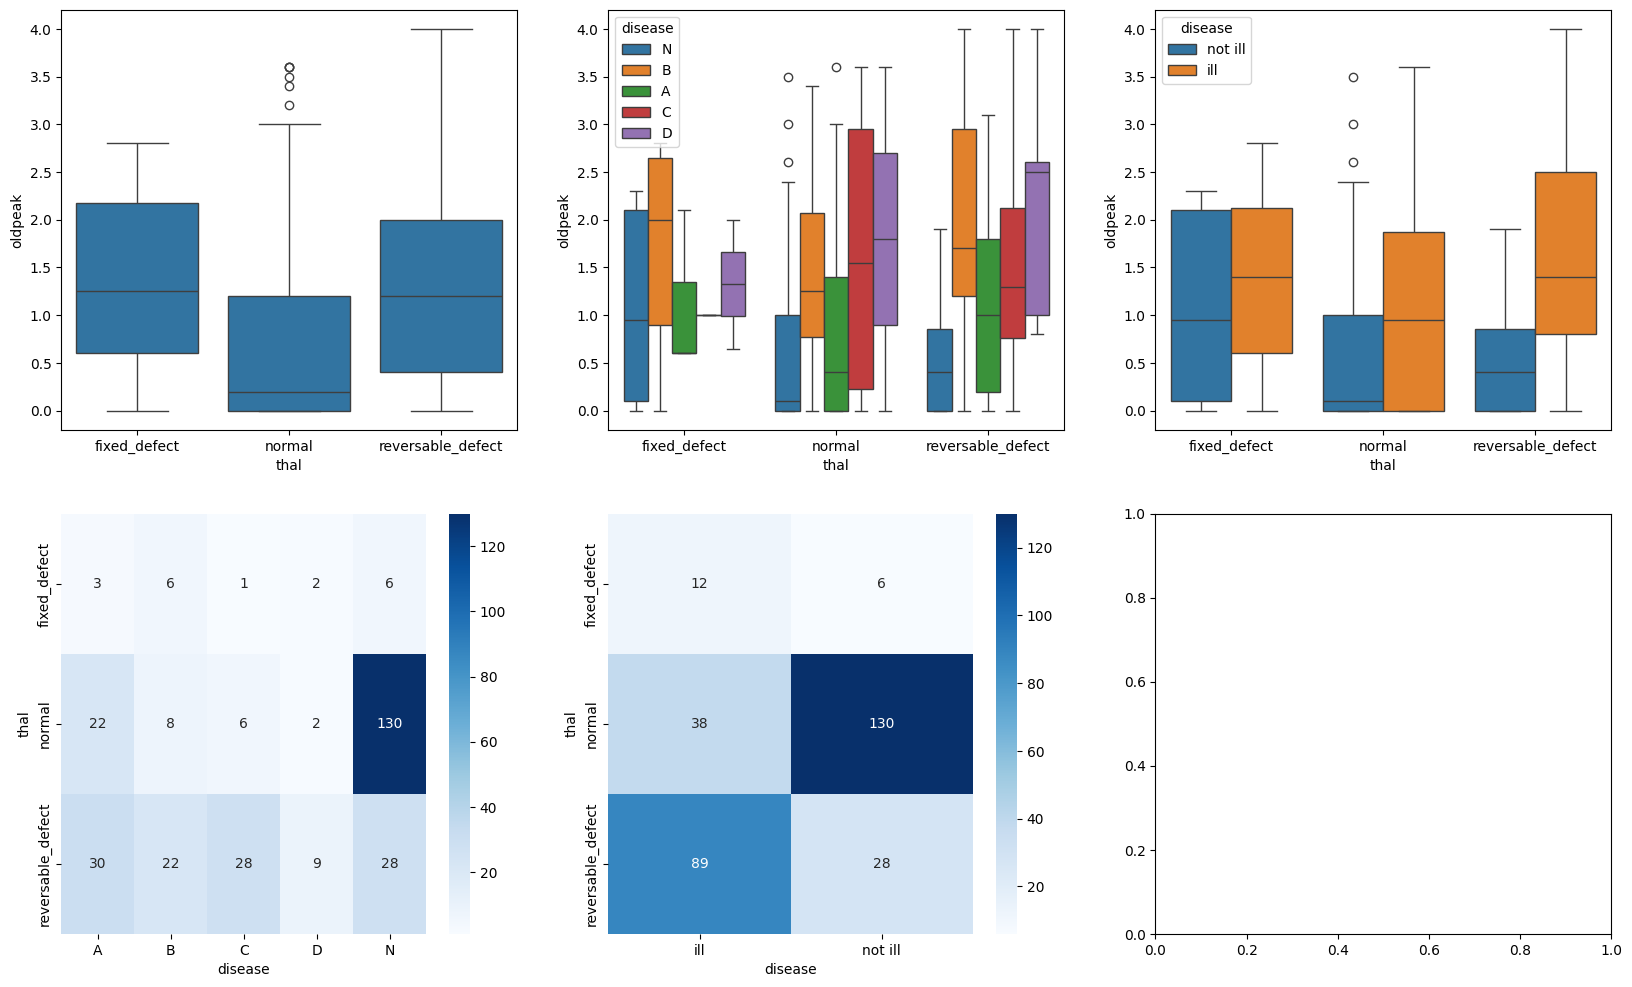

In [27]:
Valid_corrlist = ['oldpeak']
fig , ax = plt.subplots(nrows= 2 , ncols=3 , figsize = (20,12))
sns.boxplot(x= 'thal',y='oldpeak',data=data_1,ax=ax[0,0])
sns.boxplot(x= 'thal',y='oldpeak',hue='disease' ,data=data_1,ax=ax[0,1])
sns.boxplot(x= 'thal',y='oldpeak',hue=data_changed,data=data_1,ax=ax[0,2])
sns.heatmap(pd.crosstab(data_1['thal'],data_1['disease']),annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,0])
sns.heatmap(pd.crosstab(data_1['thal'],data_changed),annot=True, fmt="d", cmap="Blues", cbar=True,ax=ax[1,1])
plt.show()

in reversable defect  ill people have oldpeak more then 1 , and in others is between 0 to 2 .

### Machine learning 
#### Why we use machine learning 
**Pattern Recognition and Prediction**
ML algorithms can identify patterns and relationships within data, enabling them to make predictions or classifications. This is particularly useful in applications such as predicting stock prices, weather forecasting, and disease diagnosis.


**Automation and Efficiency**
ML allows systems to automate complex tasks and processes by learning from data. This automation can lead to increased efficiency, reduced manual effort, and faster decision-making. For example, in business, ML can automate routine tasks, such as document classification or customer support.

**Personalization**
ML models can analyze user behavior and preferences to provide personalized recommendations and experiences. This is commonly seen in applications like recommendation systems for movies, music, and products.

**Natural Language Processing (NLP)**
ML techniques are essential for understanding and processing human language. NLP enables machines to interpret and respond to human language, making it possible to build applications such as chatbots, language translation, and sentiment analysis.


**Healthcare Applications**
ML is employed in medical image analysis, drug discovery, personalized medicine, and disease prediction. It helps healthcare professionals make more accurate diagnoses and treatment decisions.


In summary, machine learning is used to harness the power of data for decision-making, automation, and improvement of various processes across diverse industries. Its versatility and ability to handle complex and unstructured data make it a valuable tool for solving a wide range of problems.

#### Methods of learning for Multi Classifications 
##### Traditional Algorithms:

**Logistic Regression**
Despite its name, logistic regression is used for classification problems. For multiclass classification, it can be extended to handle multiple classes through techniques like one-vs-rest or one-vs-one.

**Decision Trees**
Decision trees can naturally handle multiclass classification by branching into different paths for each class. Ensemble methods like Random Forests combine multiple decision trees for improved performance.

**Naive Bayes**
Naive Bayes classifiers are probabilistic models that assume independence between features. They can be extended for multiclass problems using methods like the one-vs-all approach.

**k-Nearest Neighbors (k-NN)**
k-NN is a simple and intuitive algorithm where an instance is classified based on the majority class among its k-nearest neighbors. It can be adapted for multiclass classification.


##### Modern Algorithms

**Support Vector Machines (SVM)**
SVMs are powerful classifiers that can handle multiclass problems through approaches like one-vs-one or one-vs-rest. They aim to find a hyperplane that best separates the classes in feature space.

**Neural Networks**
Deep learning, specifically neural networks, has gained popularity for multiclass classification. Architectures like feedforward neural networks, convolutional neural networks (CNNs), and recurrent neural networks (RNNs) can be used for this task.
**Gradient Boosting**
Gradient boosting algorithms, such as XGBoost, LightGBM, and CatBoost, are effective for multiclass classification. They build an ensemble of weak learners and iteratively improve model performance.
**Random Forests**
Random Forests, an ensemble of decision trees, can naturally handle multiclass problems. The majority vote from the individual trees determines the final class.

**Ensemble Methods**
Techniques like bagging and boosting are commonly used for multiclass classification. Bagging methods build multiple models independently, while boosting methods sequentially build models, giving more weight to misclassified instances.

**Multiclass SVM Extensions**
SVMs can be extended to handle multiple classes directly using methods like the Crammer-Singer method or the one-vs-one and one-vs-rest approaches.

**Deep Learning Architectures**
Architectures like CNNs and recurrent neural networks (RNNs) have been successful in handling multiclass classification tasks, especially in domains such as image recognition and natural language processing.


# Logistic Regression Overview

Logistic Regression is a statistical method used for binary classification problems, where the goal is to predict the probability that an instance belongs to a particular class. Despite its name, logistic regression is used for classification rather than regression. It's called "logistic" because it uses the logistic function (sigmoid function) to model the relationship between the independent variables and the probability of a certain outcome.

## Key Concepts:

1. **Logistic Function (Sigmoid):**
   - The logistic function is an S-shaped curve that transforms any real-valued number into a range between 0 and 1. The formula for the logistic function is: $S(z) = \frac{1}{1 + e^{-z}}$, where $z$ is the linear combination of input features and their respective weights.

2. **Linear Combination:**
   - Logistic regression models the relationship between the independent variables (features) and the log-odds (logit) of the probability of the positive class. The linear combination is represented as: $z = b_0 + b_1x_1 + b_2x_2 + \ldots + b_nx_n$, where $b_0$ is the intercept term, $b_i$ are the coefficients (weights) for each feature $x_i$.

3. **Probability Prediction:**
   - The logistic function is applied to the linear combination to produce the probability of the positive class: $P(Y=1) = \frac{1}{1 + e^{-(b_0 + b_1x_1 + b_2x_2 + \ldots + b_nx_n)}}$. The probability $P(Y=0)$ can be calculated as $1 - P(Y=1)$.

4. **Decision Boundary:**
   - A decision boundary is a threshold that separates instances into different classes based on the predicted probabilities. The common threshold is 0.5, meaning if $P(Y=1) \geq 0.5$, the instance is classified as the positive class, and vice versa.

5. **Training:**
   - The model is trained by adjusting the coefficients to minimize a cost function, typically the log-likelihood or cross-entropy loss, which measures the difference between predicted probabilities and actual labels.

6. **Regularization:**
   - Regularization terms may be added to the cost function to prevent overfitting. Common regularization techniques include L1 regularization (Lasso) and L2 regularization (Ridge).

## Prediction Process:

1. **Input Features:**
   - Collect input features $x_1, x_2, \ldots, x_n$ for an instance.

2. **Linear Combination:**
   - Calculate the linear combination $z = b_0 + b_1x_1 + b_2x_2 + \ldots + b_nx_n$.

3. **Logistic Function:**
   - Apply the logistic function to $z$ to get the predicted probability $P(Y=1)$.

4. **Decision:**
   - Make a decision based on the chosen threshold. If $P(Y=1) \geq \text{threshold}$, predict the positive class; otherwise, predict the negative class.

Logistic Regression is widely used in various applications, including medical diagnosis, credit scoring, and spam filtering, among others. It's a foundational algorithm in machine learning due to its simplicity, interpretability, and effectiveness for binary classification tasks. For multiclass problems, logistic regression can be extended using techniques like one-vs-rest or one-vs-one.

**satisfied k-fold**
Some classification problems can exhibit a large imbalance in the distribution of the target classes: for instance there could be several times more negative samples than positive samples. In such cases it is recommended to use stratified sampling as implemented in StratifiedKFold and StratifiedShuffleSplit to ensure that relative class frequencies is approximately preserved in each train and validation fold.


**How to scale the data**
1. Categorical Data:

Encoding Categorical Data:
For nominal categorical data (categories without inherent order), use one-hot encoding.
One-hot encoding creates binary columns for each category, indicating the presence or absence of that category.


2. Ordinal Data:

Ordinal Encoding:
For ordinal data (categories with a meaningful order), use ordinal encoding.
Specify the order of categories and represent them with numerical values.
The order is crucial, as the numerical values capture the ordinal relationship between categories.


3. Continuous Data:

Scaling Continuous Data:
For continuous data, especially when using algorithms sensitive to feature scales (e.g., logistic regression), apply scaling.
Standard scaling (z-score normalization) or min-max scaling helps ensure that features are on a similar scale.
This step prevents certain features from dominating the model due to their larger magnitude.

Adjust the specific encoding and scaling methods based on your dataset's characteristics and requirements.
Ensure that the encoding and scaling are consistent between the training and testing datasets to avoid data leakage.
Run each step sequentially in your workflow to maintain a structured and reproducible data preprocessing pipeline.

In [71]:
# adjusting the ordinal columns : 
list_A = []
list_B = []
list_C = []
for i in data_1.select_dtypes(object):
    if len(data_1[i].unique().tolist())>2:
        list_A.append(data_1[i].unique().tolist())
        list_B.append(i)
        list_C.append(data_2[i].unique().tolist())
list_A.pop()
print(list_A) # ordinal values for ordinal columns , in order of read 
print(list_B) # correspond columns  
print(list_C)

print(data_2)


[['typical_angina', 'asymtomatic', 'non-anginal pain', 'atypical_angina'], ['fixed_defect', 'normal', 'reversable_defect'], ['downsloping', 'flat', 'upsloping'], ['One', 'Four', 'Three', 'Two'], ['fixed_defect', 'normal', 'reversable_defect']]
['cp', 'restecg', 'slope', 'ca', 'thal', 'disease']
[['typical_angina', 'asymtomatic', 'non-anginal pain', 'atypical_angina'], ['fixed_defect', 'normal', 'reversable_defect'], ['downsloping', 'flat', 'upsloping'], ['One', 'Four', 'Three', 'Two'], ['fixed_defect', 'normal', 'reversable_defect'], [0, 2, 1, 3, 4]]
     age  sex                cp  trestbps   chol  fbs       restecg  thalach  \
0     63    1    typical_angina     145.0  233.0    1  fixed_defect    150.0   
1     67    1       asymtomatic     160.0  286.0    0  fixed_defect    108.0   
2     67    1       asymtomatic     120.0  229.0    0  fixed_defect    129.0   
3     37    1  non-anginal pain     130.0  250.0    0        normal    187.0   
4     41    0   atypical_angina     130.0  

In [72]:
# chaning the ordinal values in each data , these code is for changing each data we have with the ordinal names of data ,
#  using coding and not direct
result_list = []
for i,j,k in zip(list_B,list_A,list_C):
    key = f'{i}'
    new_dict = {}
    for m , n in zip(k,j):
            new_dict[m] = n
    result_list.append({key: new_dict})
list_B.pop()
print(result_list)
for i in result_list:
    for j in data_2.keys():
        a = list(i.keys())
        if list(i.keys())[0] == j :
            b = i[list(i.keys())[0]]
            data_2[j] = data_2[j].replace(b)
            data_mean[j] = data_mean[j].replace(b)
            data_remove[j] = data_remove[j].replace(b)
print(data_1,data_mean,data_remove,data_2)

[{'cp': {'typical_angina': 'typical_angina', 'asymtomatic': 'asymtomatic', 'non-anginal pain': 'non-anginal pain', 'atypical_angina': 'atypical_angina'}}, {'restecg': {'fixed_defect': 'fixed_defect', 'normal': 'normal', 'reversable_defect': 'reversable_defect'}}, {'slope': {'downsloping': 'downsloping', 'flat': 'flat', 'upsloping': 'upsloping'}}, {'ca': {'One': 'One', 'Four': 'Four', 'Three': 'Three', 'Two': 'Two'}}, {'thal': {'fixed_defect': 'fixed_defect', 'normal': 'normal', 'reversable_defect': 'reversable_defect'}}]
      age     sex                cp  trestbps   chol    fbs  \
0    63.0    Male    typical_angina     145.0  233.0   True   
1    67.0    Male       asymtomatic     160.0  286.0  False   
2    67.0    Male       asymtomatic     120.0  229.0  False   
3    37.0    Male  non-anginal pain     130.0  250.0  False   
4    41.0  Female   atypical_angina     130.0  204.0  False   
..    ...     ...               ...       ...    ...    ...   
298  45.0    Male    typical_ang

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
list_B.extend(['sex','fbs','exang'])
Target = data_2['disease']
data_3 = data_2.drop('disease',axis=1)
list_continous = list(data_1.select_dtypes('float64'))
# binary_data = ['sex','fbs','exang','disease']
# ordinal_data_names = [name for name in list_B if name not in binary_data]
# print(list_continous,list_B)
# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), list_B),
        ('continuous', StandardScaler(), list_continous)
    ]
)

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(data_3, Target, test_size=0.3, random_state=42,stratify=Target)#median
X_train1, X_test1, y_train1, y_test1 = train_test_split(data_3, Target, test_size=0.3, random_state=42)#median with no stratify

X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean, Target, test_size=0.3, random_state=42, stratify=Target)  

X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove, data_target_remove, test_size=0.3, random_state=42,stratify=data_target_remove)#remove


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = LogisticRegression(solver='saga',multi_class='ovr',max_iter=1000,class_weight='balanced')
log_model1 = LogisticRegression(solver='saga',multi_class='ovr',max_iter=1000,class_weight='balanced')
log_model_mean = LogisticRegression(solver='saga',multi_class='ovr',max_iter=1000,class_weight='balanced')
log_model_remove = LogisticRegression(solver='saga',multi_class='ovr',max_iter=1000,class_weight='balanced')


# Create a Pipeline with the preprocessing steps and the logistic regression model
pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model)
])


pipeline_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model1)
])


pipeline_mean = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model_mean)
])

pipeline_remove = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model_remove)
])

pipeline_1.fit(X_train, y_train)
y_pred = pipeline_1.predict(X_test)

pipeline_2.fit(X_train1, y_train1)
y_pred1 = pipeline_2.predict(X_test1)

pipeline_mean.fit(X_train_mean, y_train_mean)
y_pred_mean = pipeline_mean.predict(X_test_mean)

pipeline_remove.fit(X_train_remove, y_train_remove)
y_pred_remove = pipeline_remove.predict(X_test_remove)



C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_sag.py:350: Conve

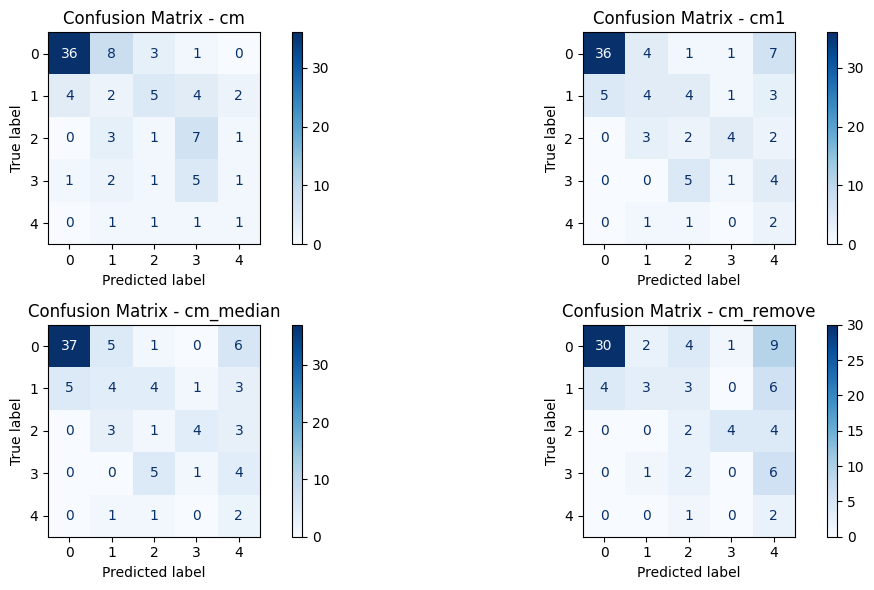

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ,ConfusionMatrixDisplay

cm = confusion_matrix(y_test1,y_pred1)
cm1 = confusion_matrix(y_test,y_pred)
cm_median = confusion_matrix(y_test_mean,y_pred_mean)
cm_remove = confusion_matrix(y_test_remove,y_pred_remove)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
# Plot for cm
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_cm.plot(ax=ax[0, 0], cmap='Blues', values_format='d')
ax[0, 0].set_title('Confusion Matrix - cm')

# Plot for cm1
disp_cm1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp_cm1.plot(ax=ax[0, 1], cmap='Blues', values_format='d')
ax[0, 1].set_title('Confusion Matrix - cm1')

# Plot for cm_median
disp_cm_median = ConfusionMatrixDisplay(confusion_matrix=cm_median)
disp_cm_median.plot(ax=ax[1, 0], cmap='Blues', values_format='d')
ax[1, 0].set_title('Confusion Matrix - cm_median')

# Plot for cm_remove
disp_cm_remove = ConfusionMatrixDisplay(confusion_matrix=cm_remove)
disp_cm_remove.plot(ax=ax[1, 1], cmap='Blues', values_format='d')
ax[1, 1].set_title('Confusion Matrix - cm_remove')

plt.tight_layout()
plt.show()




In [76]:
logreg_model = pipeline_1.named_steps['classifier']

# Access the coefficients
coefficients = logreg_model.coef_

# Get feature names after preprocessing
encoded_feature_names = pipeline_1.named_steps['preprocessor'].named_transformers_['ordinal'].get_feature_names_out()
continuous_feature_names = list_continous
feature_names = list(encoded_feature_names) + list(continuous_feature_names)

# Create a DataFrame to display the coefficients
coefficients_df = pd.DataFrame(coefficients, columns=feature_names)

# Display the coefficient matrix
print("Coefficient Matrix:first\n")
print(coefficients_df)
# second model  ------------------------------

logreg_model2 = pipeline_2.named_steps['classifier']

# Access the coefficients
coefficients2 = logreg_model.coef_

# Get feature names after preprocessing
encoded_feature_names2 = pipeline_2.named_steps['preprocessor'].named_transformers_['ordinal'].get_feature_names_out()
continuous_feature_names2 = list_continous
feature_names2 = list(encoded_feature_names2) + list(continuous_feature_names2)

# Create a DataFrame to display the coefficients
coefficients_df2 = pd.DataFrame(coefficients2, columns=feature_names2)

# Display the coefficient matrix
print("Coefficient Matrix:second \n")
print(coefficients_df2)

#--------- third model 



logreg_model3 = pipeline_1.named_steps['classifier']

# Access the coefficients
coefficients3 = logreg_model.coef_

# Get feature names after preprocessing
encoded_feature_names3 = pipeline_mean.named_steps['preprocessor'].named_transformers_['ordinal'].get_feature_names_out()
continuous_feature_names3 = list_continous
feature_names3 = list(encoded_feature_names3) + list(continuous_feature_names3)

# Create a DataFrame to display the coefficients
coefficients_df3 = pd.DataFrame(coefficients3, columns=feature_names3)

# Display the coefficient matrix
print("Coefficient Matrix:third\n")
print(coefficients_df3)

#--------- fourth model --------


logreg_model4 = pipeline_1.named_steps['classifier']

# Access the coefficients
coefficients4 = logreg_model.coef_

# Get feature names after preprocessing
encoded_feature_names4 = pipeline_remove.named_steps['preprocessor'].named_transformers_['ordinal'].get_feature_names_out()
continuous_feature_names4 = list_continous
feature_names4 = list(encoded_feature_names4) + list(continuous_feature_names4)

# Create a DataFrame to display the coefficients
coefficients_df4 = pd.DataFrame(coefficients4, columns=feature_names4)

# Display the coefficient matrix
print("Coefficient Matrix:fourth\n")
print(coefficients_df4)

Coefficient Matrix:first

         cp   restecg     slope        ca      thal       sex       fbs  \
0  1.040548  0.517404  0.357729 -0.706660 -0.941905 -1.447611 -0.193797   
1 -0.220596 -0.529919  0.317660  0.357294  0.261715  0.944614 -0.720620   
2 -0.794790  0.186402 -0.927461  0.504038 -0.708424  1.441149  0.667809   
3 -0.526747 -0.598563 -0.350614  0.315511  2.254488  0.186940  1.252338   
4 -0.061185 -2.957362  0.230795 -1.662571  0.573338  1.590095 -1.902980   

      exang       age  trestbps      chol   thalach   oldpeak  
0 -0.651490 -0.292544 -0.484091 -0.342185  0.324008 -0.774448  
1  0.667605  0.137405  0.213602  0.109611  0.199992 -0.028603  
2 -0.386925  0.506053 -0.064451  0.768633 -0.713577  0.515944  
3  0.319032 -0.159690  0.062180 -0.032522 -0.517060 -0.147503  
4 -1.285546  2.787667 -0.530073 -1.312232  1.378418  3.636835  
Coefficient Matrix:second 

         cp   restecg     slope        ca      thal       sex       fbs  \
0  1.040548  0.517404  0.357729 -0.7

In [77]:
accuracy = accuracy_score(y_test, y_pred)
classification_report_result = classification_report(y_test, y_pred)

print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print('no stratify ')

print(classification_report(y_test1,y_pred1))
print(accuracy_score(y_test1,y_pred1))


print('percision of mean filling')
print(classification_report(y_test_mean,y_pred_mean))
print(accuracy_score(y_test_mean,y_pred))


print('percision of removing nulls')
print(classification_report(y_test_remove ,y_pred_remove))
print(accuracy_score(y_test_remove,y_pred_remove))

 

              precision    recall  f1-score   support

           0       0.88      0.73      0.80        49
           1       0.33      0.24      0.28        17
           2       0.15      0.18      0.17        11
           3       0.14      0.10      0.12        10
           4       0.11      0.50      0.18         4

    accuracy                           0.49        91
   macro avg       0.32      0.35      0.31        91
weighted avg       0.57      0.49      0.52        91

0.4945054945054945
no stratify 
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        48
           1       0.12      0.12      0.12        17
           2       0.09      0.08      0.09        12
           3       0.28      0.50      0.36        10
           4       0.20      0.25      0.22         4

    accuracy                           0.49        91
   macro avg       0.31      0.34      0.32        91
weighted avg       0.54      0.49      0.51  

# Decision Trees Explained

## Gini Impurity (for Classification):

For a dataset with $K$ classes, the Gini impurity ($G$) for a node is calculated as:

$$ G = 1 - \sum_{i=1}^{K} p_i^2 $$

Where:
- $ p_i $ is the proportion of samples in the node that belong to class $i$.

The Gini impurity for a split is the weighted sum of impurities in the child nodes:

$$ G_{\text{split}} = \frac{N_{\text{left}}}{N_{\text{total}}} G_{\text{left}} + \frac{N_{\text{right}}}{N_{\text{total}}} G_{\text{right}} $$

The goal is to find splits that minimize the Gini impurity.

## Mean Squared Error (for Regression):

For regression problems, the Mean Squared Error (MSE) is commonly used. The MSE for a node is calculated as:

$$ \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \bar{y})^2 $$

Where:
- $ N $ is the number of samples in the node.
- $ y_i $ is the target value for the $i$-th sample.
- $ \bar{y} $ is the mean target value in the node.

The MSE for a split is the weighted sum of MSE in the child nodes:

$$ \text{MSE}_{\text{split}} = \frac{N_{\text{left}}}{N_{\text{total}}} \text{MSE}_{\text{left}} + \frac{N_{\text{right}}}{N_{\text{total}}} \text{MSE}_{\text{right}} $$

Again, the goal is to find splits that minimize the MSE.

## Splitting Process:

The decision tree algorithm iteratively selects features and thresholds to minimize the impurity or MSE at each node. This process is recursive, creating a tree structure until a stopping criterion is met (e.g., maximum depth, minimum samples per leaf).

The mathematical expressions guide the algorithm in making decisions that lead to homogeneous child nodes, enhancing the predictive power of the model.


In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), list_B),
        ('continuous', StandardScaler(), list_continous)
    ]
    
)

X_train, X_test, y_train, y_test = train_test_split(data_3, Target, test_size=0.3, random_state=42,stratify=Target)#median
X_train1, X_test1, y_train1, y_test1 = train_test_split(data_3, Target, test_size=0.3, random_state=42)#median with no stratify

X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean, Target, test_size=0.3, random_state=42, stratify=Target)  

X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove, data_target_remove, test_size=0.3, random_state=42,stratify=data_target_remove)#remove

log_model = DecisionTreeClassifier(random_state=42,class_weight='balanced')
log_model1 = DecisionTreeClassifier(random_state=42,class_weight='balanced')
log_model_mean = DecisionTreeClassifier(random_state=42,class_weight='balanced')
log_model_remove = DecisionTreeClassifier(random_state=42,class_weight='balanced')


pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model)
])


pipeline_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model1)
])


pipeline_mean = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model_mean)
])

pipeline_remove = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_model_remove)
])

pipeline_1.fit(X_train, y_train)
y_pred = pipeline_1.predict(X_test)

pipeline_2.fit(X_train1, y_train1)
y_pred1 = pipeline_2.predict(X_test1)

pipeline_mean.fit(X_train_mean, y_train_mean)
y_pred_mean = pipeline_mean.predict(X_test_mean)

pipeline_remove.fit(X_train_remove, y_train_remove)
y_pred_remove = pipeline_remove.predict(X_test_remove)



accuracy = accuracy_score(y_test, y_pred)

print(accuracy_score(y_test,y_pred))
print('no stratify ')

print(accuracy_score(y_test1,y_pred1))


print('percision of mean filling')
print(accuracy_score(y_test_mean,y_pred))


print('percision of removing nulls')
print(accuracy_score(y_test_remove,y_pred_remove))



0.43956043956043955
no stratify 
0.46153846153846156
percision of mean filling
0.43956043956043955
percision of removing nulls
0.4880952380952381


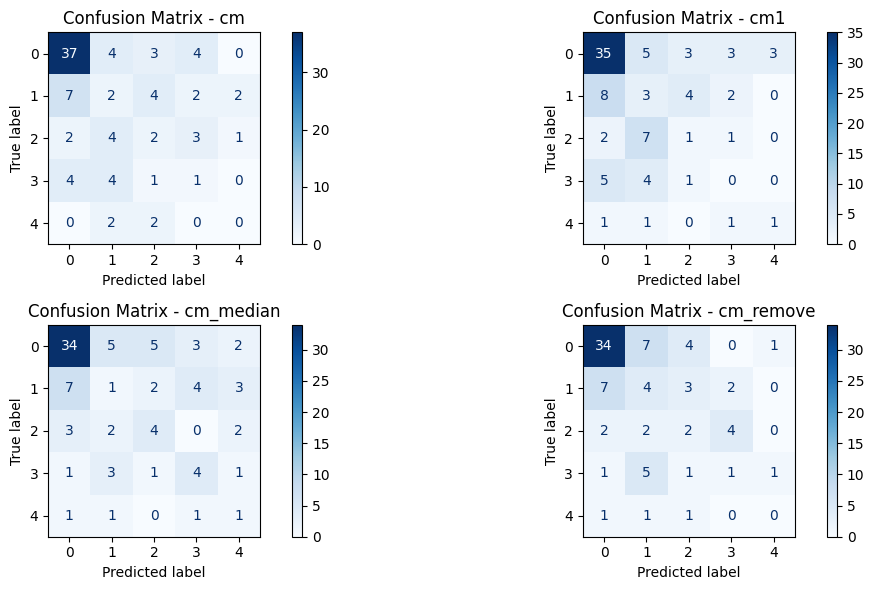

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ,ConfusionMatrixDisplay

cm = confusion_matrix(y_test1,y_pred1)
cm1 = confusion_matrix(y_test,y_pred)
cm_median = confusion_matrix(y_test_mean,y_pred_mean)
cm_remove = confusion_matrix(y_test_remove,y_pred_remove)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
# Plot for cm
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_cm.plot(ax=ax[0, 0], cmap='Blues', values_format='d')
ax[0, 0].set_title('Confusion Matrix - cm')

# Plot for cm1
disp_cm1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp_cm1.plot(ax=ax[0, 1], cmap='Blues', values_format='d')
ax[0, 1].set_title('Confusion Matrix - cm1')

# Plot for cm_median
disp_cm_median = ConfusionMatrixDisplay(confusion_matrix=cm_median)
disp_cm_median.plot(ax=ax[1, 0], cmap='Blues', values_format='d')
ax[1, 0].set_title('Confusion Matrix - cm_median')

# Plot for cm_remove
disp_cm_remove = ConfusionMatrixDisplay(confusion_matrix=cm_remove)
disp_cm_remove.plot(ax=ax[1, 1], cmap='Blues', values_format='d')
ax[1, 1].set_title('Confusion Matrix - cm_remove')

plt.tight_layout()
plt.show()




# Support Vector Machines (SVM) for Classification

## Introduction:

Support Vector Machines (SVM) is a versatile machine learning algorithm employed for both classification and regression tasks. In classification, SVM seeks to find a hyperplane that optimally separates the data into distinct classes.

## Decision Function:

The decision function of SVM is expressed as:

$$ f(x) = \text{sign}\left(\sum_{i=1}^{N} \alpha_i y_i K(x, x_i) + b\right) $$

Where:
* $ f(x) $ is the decision function.
* $ N $ is the number of support vectors.
* $ \alpha_i $ is the Lagrange multiplier for the $i$-th support vector.
* $ y_i $ is the class label for the $i$-th support vector.
* $ K(x, x_i) $ is the kernel function, computing the dot product of $ x $ and $ x_i $ in the transformed feature space.
* $ b $ is the bias term.

## Objective Function:

SVM formulates the following optimization problem:

$$ \text{minimize} \left( \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j K(x_i, x_j) - \sum_{i=1}^{N} \alpha_i \right) $$

Subject to the constraints:
$$ 0 \leq \alpha_i \leq C $$
$$ \sum_{i=1}^{N} \alpha_i y_i = 0 $$

Where:
- \( C \) is the regularization parameter.
- The first term encourages maximizing the margin between classes.
- The second term penalizes misclassifications.

## Kernel Trick:

SVM employs the kernel trick to implicitly map input features into high-dimensional spaces, making it effective for non-linear classification tasks. Common kernel functions include linear, polynomial, and radial basis function (RBF).

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), list_B),
        ('continuous', StandardScaler(), list_continous)
    ]
    
)

X_train, X_test, y_train, y_test = train_test_split(data_3, Target, test_size=0.3, random_state=42,stratify=Target)#median
X_train1, X_test1, y_train1, y_test1 = train_test_split(data_3, Target, test_size=0.3, random_state=42)#median with no stratify

X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean, Target, test_size=0.3, random_state=42, stratify=Target)  

X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove, data_target_remove, test_size=0.3, random_state=42,stratify=data_target_remove)#remove

SVC_model = SVC(kernel='linear', C=1.0)
SVC_model1 = SVC(kernel='linear', C=1.0)
SVC_model_mean = SVC(kernel='linear', C=1.0)
SVC_model_remove = SVC(kernel='linear', C=1.0)

pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC_model)
])


pipeline_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC_model1)
])


pipeline_mean = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC_model_mean)
])

pipeline_remove = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC_model_remove)
])



In [81]:
pipeline_1.fit(X_train, y_train)
y_pred = pipeline_1.predict(X_test)

pipeline_2.fit(X_train1, y_train1)
y_pred1 = pipeline_2.predict(X_test1)

pipeline_mean.fit(X_train_mean, y_train_mean)
y_pred_mean = pipeline_mean.predict(X_test_mean)

pipeline_remove.fit(X_train_remove, y_train_remove)
y_pred_remove = pipeline_remove.predict(X_test_remove)



accuracy = accuracy_score(y_test, y_pred)

print(accuracy_score(y_test,y_pred))
print('no stratify ')

print(accuracy_score(y_test1,y_pred1))


print('percision of mean filling')
print(accuracy_score(y_test_mean,y_pred))


print('percision of removing nulls')
print(accuracy_score(y_test_remove,y_pred_remove))

0.5494505494505495
no stratify 
0.6043956043956044
percision of mean filling
0.5494505494505495
percision of removing nulls
0.5833333333333334


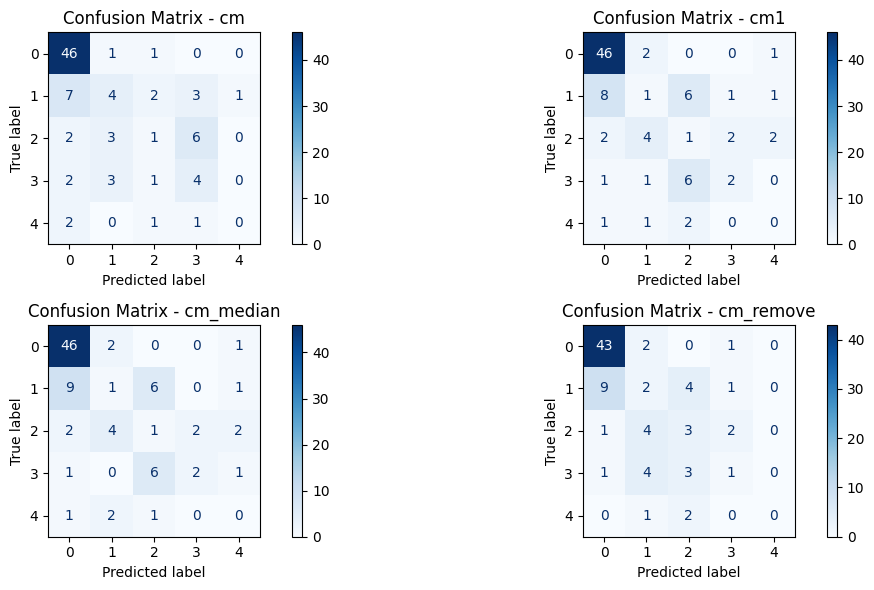

In [82]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ,ConfusionMatrixDisplay

cm = confusion_matrix(y_test1,y_pred1)
cm1 = confusion_matrix(y_test,y_pred)
cm_median = confusion_matrix(y_test_mean,y_pred_mean)
cm_remove = confusion_matrix(y_test_remove,y_pred_remove)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
# Plot for cm
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_cm.plot(ax=ax[0, 0], cmap='Blues', values_format='d')
ax[0, 0].set_title('Confusion Matrix - cm')

# Plot for cm1
disp_cm1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp_cm1.plot(ax=ax[0, 1], cmap='Blues', values_format='d')
ax[0, 1].set_title('Confusion Matrix - cm1')

# Plot for cm_median
disp_cm_median = ConfusionMatrixDisplay(confusion_matrix=cm_median)
disp_cm_median.plot(ax=ax[1, 0], cmap='Blues', values_format='d')
ax[1, 0].set_title('Confusion Matrix - cm_median')

# Plot for cm_remove
disp_cm_remove = ConfusionMatrixDisplay(confusion_matrix=cm_remove)
disp_cm_remove.plot(ax=ax[1, 1], cmap='Blues', values_format='d')
ax[1, 1].set_title('Confusion Matrix - cm_remove')

plt.tight_layout()
plt.show()




### Random Forest Overview:

1. **Bootstrapped Sampling:**
   - **Math:** For each tree in the forest, a random subset of the training data is sampled with replacement (bootstrapping).
   - **Method:** Randomly select a subset of the data with replacement to create diverse training sets for individual trees.

2. **Feature Randomization:**
   - **Math:** At each split in a tree, only a random subset of features is considered.
   - **Method:** Randomly select a subset of features to be used for determining the best split at each node.

3. **Building Decision Trees:**
   - **Math:** Each tree in the forest is grown by recursively splitting nodes based on the best split among the randomly selected features.
   - **Method:** Build decision trees using the random subsets of data and features.

4. **Voting or Averaging:**
   - **Math:** For classification, each tree "votes" for a class, and the class with the most votes becomes the predicted class. For regression, the predictions of individual trees are averaged.
   - **Method:** Aggregate predictions by majority voting (classification) or averaging (regression) across all trees in the forest.

### Math Behind Decision Tree Splits:

#### 1. Entropy (for Classification) or Variance Reduction (for Regression):
   - The decision tree aims to minimize entropy (measure of impurity) for classification tasks or maximize variance reduction for regression tasks.
   - For classification, entropy is calculated as: $H(D) = - \sum_{i=1}^{C} p_i \log_2(p_i)$, where $p_i$ is the proportion of samples in class $i$ in the dataset $D$.

#### 2. Information Gain (for Classification):
   - At each split, the algorithm calculates the information gain to determine the best feature to split on.
   - Information Gain = Entropy before split - Weighted sum of entropies after split.

#### 3. Gini Impurity (for Classification):
   - An alternative metric to entropy, Gini impurity is used for measuring impurity in a dataset.
   - Gini Impurity = $1 - \sum_{i=1}^{C} p_i^2$, where $p_i$ is the proportion of samples in class $i$.


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), list_B),
        ('continuous', StandardScaler(), list_continous)
    ]
    
)

X_train, X_test, y_train, y_test = train_test_split(data_3, Target, test_size=0.3, random_state=42,stratify=Target)#median
X_train1, X_test1, y_train1, y_test1 = train_test_split(data_3, Target, test_size=0.3, random_state=42)#median with no stratify

X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean, Target, test_size=0.3, random_state=42, stratify=Target)  

X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove, data_target_remove, test_size=0.3, random_state=42,stratify=data_target_remove)#remove
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

Rndom_Forest = RandomForestClassifier(n_estimators=100, random_state=42)

Rndom_Forest1 = RandomForestClassifier(n_estimators=100, random_state=42)

Rndom_Forest_mean = RandomForestClassifier(n_estimators=100, random_state=42)

Rndom_Forest_remove = RandomForestClassifier(n_estimators=100, random_state=42)


pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', Rndom_Forest)
])


pipeline_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', Rndom_Forest1)
])


pipeline_mean = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', Rndom_Forest_mean)
])

pipeline_remove = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', Rndom_Forest_remove)
])
pipeline_1.fit(X_train, y_train)
y_pred = pipeline_1.predict(X_test)

pipeline_2.fit(X_train1, y_train1)
y_pred1 = pipeline_2.predict(X_test1)

pipeline_mean.fit(X_train_mean, y_train_mean)
y_pred_mean = pipeline_mean.predict(X_test_mean)

pipeline_remove.fit(X_train_remove, y_train_remove)
y_pred_remove = pipeline_remove.predict(X_test_remove)



accuracy = accuracy_score(y_test, y_pred)

print(accuracy_score(y_test,y_pred))
print('no stratify ')

print(accuracy_score(y_test1,y_pred1))

print('percision of mean filling')
print(accuracy_score(y_test_mean,y_pred))


print('percision of removing nulls')
print(accuracy_score(y_test_remove,y_pred_remove))

0.5604395604395604
no stratify 
0.5494505494505495
percision of mean filling
0.5604395604395604
percision of removing nulls
0.5476190476190477


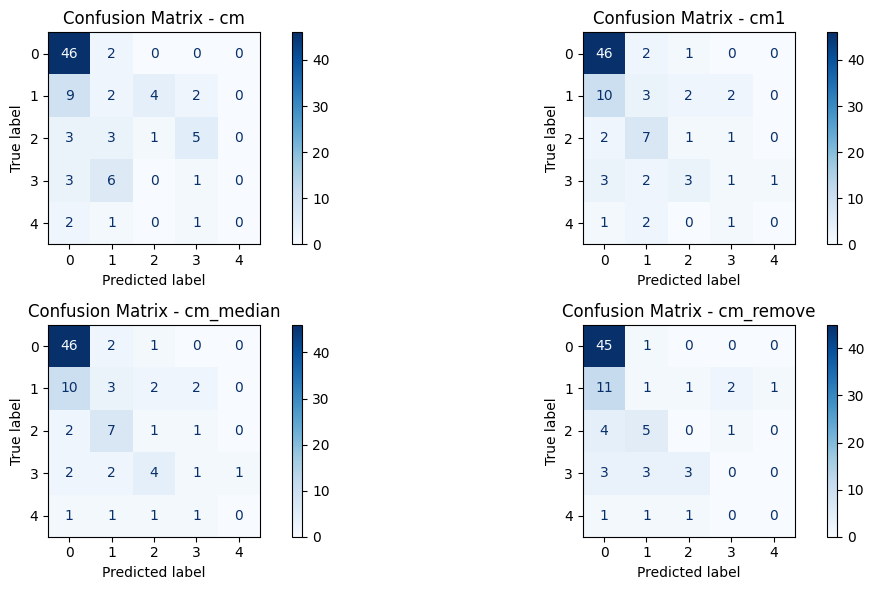

In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ,ConfusionMatrixDisplay

cm = confusion_matrix(y_test1,y_pred1)
cm1 = confusion_matrix(y_test,y_pred)
cm_median = confusion_matrix(y_test_mean,y_pred_mean)
cm_remove = confusion_matrix(y_test_remove,y_pred_remove)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
# Plot for cm
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_cm.plot(ax=ax[0, 0], cmap='Blues', values_format='d')
ax[0, 0].set_title('Confusion Matrix - cm')

# Plot for cm1
disp_cm1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp_cm1.plot(ax=ax[0, 1], cmap='Blues', values_format='d')
ax[0, 1].set_title('Confusion Matrix - cm1')

# Plot for cm_median
disp_cm_median = ConfusionMatrixDisplay(confusion_matrix=cm_median)
disp_cm_median.plot(ax=ax[1, 0], cmap='Blues', values_format='d')
ax[1, 0].set_title('Confusion Matrix - cm_median')

# Plot for cm_remove
disp_cm_remove = ConfusionMatrixDisplay(confusion_matrix=cm_remove)
disp_cm_remove.plot(ax=ax[1, 1], cmap='Blues', values_format='d')
ax[1, 1].set_title('Confusion Matrix - cm_remove')

plt.tight_layout()
plt.show()




In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
from sklearn.linear_model import LinearRegression

data_temp = data_1.drop("trestbps" , axis= 1)  #using trestbps , maximum heart rate . 
Target = data_1['trestbps']
# print(Target)
data_mean_temp = data_mean.drop('trestbps',axis= 1)
data_remove_temp = data_remove.drop('trestbps',axis= 1)
# print(data_temp , data_mean_temp , data_remove_temp)
data_targetRemove =  data_remove['trestbps']
# print(data_remove_temp,data_targetRemove)
temp_ordinal = list_B
print(list_B)
# temp_ordinal.append('disease')
temp_continus = [index for index in list_continous if index != 'trestbps']
# print(temp_ordinal,temp_continus )

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), temp_ordinal),
        ('continuous', StandardScaler(), temp_continus)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(data_temp, Target, test_size=0.3, random_state=42)#median
# X_train1, X_test1, y_train1, y_test1 = train_test_split(data_temp, Target, test_size=0.3, random_state=42)#median with no stratify
X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean_temp, Target, test_size=0.3, random_state=42)  
# X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove_temp, data_targetRemove, test_size=0.3, random_state=42)#remove


pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('regression', LinearRegression())
])


# pipeline_2 = Pipeline([
#     ('preprocessor', preprocessor),
#     ('regression', LinearRegression())
# ])


pipeline_mean = Pipeline([
    ('preprocessor', preprocessor),
    ('regression', LinearRegression())
])

# pipeline_remove = Pipeline([
#     ('preprocessor', preprocessor),
#     ('regression', LinearRegression())
# ])


pipeline_1.fit(X_train, y_train)
y_pred = pipeline_1.predict(X_test)

# pipeline_2.fit(X_train1, y_train1)
# y_pred1 = pipeline_2.predict(X_test1)

pipeline_mean.fit(X_train_mean, y_train_mean)
y_pred_mean = pipeline_mean.predict(X_test_mean)

# pipeline_remove.fit(X_train_remove, y_train_remove)
# y_pred_remove = pipeline_remove.predict(X_test_remove)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# mse_remove = mean_squared_error(y_test_remove, y_pred_remove)
# print('MSE of removing nulls:', mse_remove)
coefficients_median = pipeline_1.named_steps['regression'].coef_
coefficients_mean = pipeline_mean.named_steps['regression'].coef_

transformed_feature_names = pipeline_1.named_steps['preprocessor'].get_feature_names_out()
print(transformed_feature_names)
print("Queffs for the median method : " ,coefficients_median)
print("\n Queffs for the mean method : " ,coefficients_mean)



['cp', 'restecg', 'slope', 'ca', 'thal', 'sex', 'fbs', 'exang']
Mean Absolute Error (MAE): 11.39248910943833
Mean Squared Error (MSE): 201.5851291224188
Root Mean Squared Error (RMSE): 14.19806779538747
R-squared (R2): -0.08080738085457728
['ordinal__cp' 'ordinal__restecg' 'ordinal__slope' 'ordinal__ca'
 'ordinal__thal' 'ordinal__sex' 'ordinal__fbs' 'ordinal__exang'
 'continuous__age' 'continuous__chol' 'continuous__thalach'
 'continuous__oldpeak']
Queffs for the median method :  [ 1.29556019 -1.08062309 -0.64325209 -3.45839806 -1.08062309  1.76365298
  2.05990096  0.38292916  4.82308931  0.5280792   0.87987185  2.49197867]

 Queffs for the mean method :  [ 1.44634296 -3.67446586 -0.25277345 -3.46738804 -2.11431042  1.71108698
  2.07510432  0.53209297  4.68881602  0.30826729  0.94741663  2.47177328]


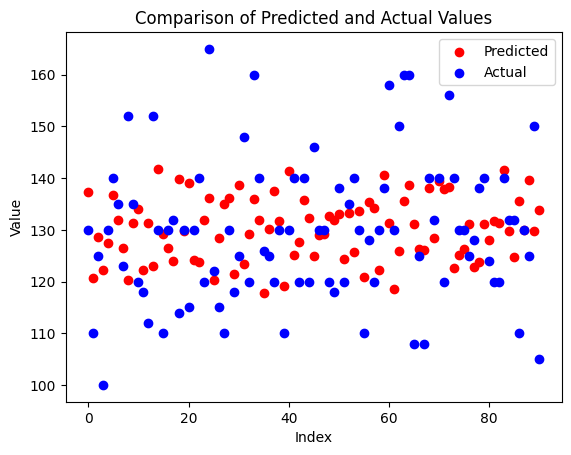

In [86]:
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted')
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of Predicted and Actual Values')
plt.show()


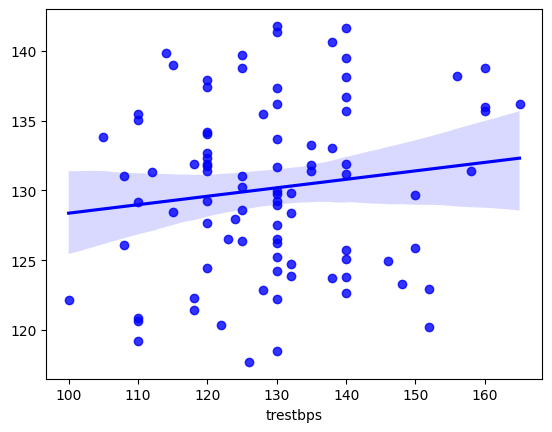

In [87]:
sns.regplot(x = y_test, y =y_pred, color='blue', label='Predicted')

# sns.lineplot(x = y_test,y = y_pred)

plt.show()

In [88]:
def evaluate(y_true, y_pred, interval_percentage):
    error = mean_absolute_error(y_true, y_pred)

    interval = interval_percentage / 100.0 * (y_true.max() - y_true.min())

    lower_bound = y_true - interval
    upper_bound = y_true + interval

    in_interval = ((y_pred >= lower_bound) & (y_pred <= upper_bound)).sum()

    interval_accuracy = in_interval / len(y_true) * 100.0

    return error, interval_accuracy, interval
error , accuracy , interval = evaluate(y_test,y_pred,10)
print("error : ",error ,"acuracy :", accuracy ,"distance " ,interval)

error :  11.39248910943833 acuracy : 38.46153846153847 distance  6.5


In [94]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
num_classes = 5 
label_encoder = LabelEncoder()
Target = data_1['disease']
Target = label_encoder.fit_transform(Target)
print(data_3,Target,data_target_remove,list_B,list_continous)

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), list_B),
        ('continuous', StandardScaler(), list_continous)
    ]
    
)

data_4 = preprocessor.fit_transform(data_3)
data_mean_temp = preprocessor.fit_transform(data_mean)
data_remove_temp = preprocessor.fit_transform(data_remove)
print(data_3)

X_train, X_test, y_train, y_test = train_test_split(data_4, Target, test_size=0.3, random_state=42,stratify=Target)#median
X_train1, X_test1, y_train1, y_test1 = train_test_split(data_4, Target, test_size=0.3, random_state=42)#median with no stratify
X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean_temp, Target, test_size=0.3, random_state=42, stratify=Target)  
X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove_temp, data_target_remove, test_size=0.3, random_state=42,stratify=data_target_remove)#remove



model = tf.keras.Sequential([
        tf.keras.layers.Dense(units=64, activation='relu'),
        tf.keras.layers.Dense(units=num_classes, activation='softmax')
    ])
model_mediandf = tf.keras.Sequential([
        tf.keras.layers.Dense(units=64, activation='relu'),
        tf.keras.layers.Dense(units=num_classes, activation='softmax')
    ])
model_mean= tf.keras.Sequential([
        tf.keras.layers.Dense(units=64, activation='relu'),
        tf.keras.layers.Dense(units=num_classes, activation='softmax')
    ])
model_remove = tf.keras.Sequential([
        tf.keras.layers.Dense(units=64, activation='relu'),
        tf.keras.layers.Dense(units=num_classes, activation='softmax')
    ])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_mediandf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_mean.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_remove.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)
history_mediandf = model_mediandf.fit(X_train, y_train, epochs=10, validation_split=0.2)
history_mean = model_mean.fit(X_train, y_train, epochs=10, validation_split=0.2)
history_renove = model_remove.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)


# Evaluate the pipeline
test_loss, test_acc = model_mediandf.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)


# Evaluate the model trained with median data
test_loss_median, test_acc_median = model_mean.evaluate(X_test, y_test)
print('Test accuracy (median):', test_acc_median)

# Evaluate the model trained with mean data
test_loss_mean, test_acc_mean = model_remove.evaluate(X_test_mean, y_test_mean)
print('Test accuracy (mean):', test_acc_mean)



     age  sex                cp  trestbps   chol  fbs       restecg  thalach  \
0     63    1    typical_angina     145.0  233.0    1  fixed_defect    150.0   
1     67    1       asymtomatic     160.0  286.0    0  fixed_defect    108.0   
2     67    1       asymtomatic     120.0  229.0    0  fixed_defect    129.0   
3     37    1  non-anginal pain     130.0  250.0    0        normal    187.0   
4     41    0   atypical_angina     130.0  204.0    0  fixed_defect    172.0   
..   ...  ...               ...       ...    ...  ...           ...      ...   
298   45    1    typical_angina     110.0  264.0    0        normal    132.0   
299   68    1       asymtomatic     144.0  193.0    1        normal    141.0   
300   57    1       asymtomatic     130.0  131.0    0        normal    115.0   
301   57    0   atypical_angina     130.0  236.0    0  fixed_defect    174.0   
302   38    1  non-anginal pain     138.0  175.0    0        normal    173.0   

     exang  oldpeak        slope     ca

In [ ]:
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
# num_classes = 5 
# label_encoder = LabelEncoder()
# Target = data_1['disease']
# Target = label_encoder.fit_transform(Target)
# print(data_3,Target,data_target_remove,list_B,list_continous)

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('ordinal', OrdinalEncoder(), list_B),
#         ('continuous', StandardScaler(), list_continous)
#     ]
    
# )

# X_train, X_test, y_train, y_test = train_test_split(data_3, Target, test_size=0.3, random_state=42,stratify=Target)#median
# X_train1, X_test1, y_train1, y_test1 = train_test_split(data_3, Target, test_size=0.3, random_state=42)#median with no stratify

# X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(data_mean, Target, test_size=0.3, random_state=42, stratify=Target)  

# X_train_remove, X_test_remove, y_train_remove, y_test_remove  = train_test_split(data_remove, data_target_remove, test_size=0.3, random_state=42,stratify=data_target_remove)#remove

# model = tf.keras.Sequential([
#         tf.keras.layers.Dense(units=64, activation='relu'),
#         tf.keras.layers.Dense(units=num_classes, activation='softmax')
#     ])
# model_mediandf = tf.keras.Sequential([
#         tf.keras.layers.Dense(units=64, activation='relu'),
#         tf.keras.layers.Dense(units=num_classes, activation='softmax')
#     ])
# model_mean= tf.keras.Sequential([
#         tf.keras.layers.Dense(units=64, activation='relu'),
#         tf.keras.layers.Dense(units=num_classes, activation='softmax')
#     ])
# model_remove = tf.keras.Sequential([
#         tf.keras.layers.Dense(units=64, activation='relu'),
#         tf.keras.layers.Dense(units=num_classes, activation='softmax')
#     ])



# pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', model)
# ])
# pipeline_mediandf = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', model_mediandf)
# ])
# pipeline_mean = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier',model_mean)
# ])
# pipeline_remove = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', model_remove)
# ])

# # Compile the pipeline
# pipeline.named_steps['classifier'].compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# pipeline_mediandf.named_steps['classifier'].compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# pipeline_mean.named_steps['classifier'].compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# pipeline_remove.named_steps['classifier'].compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])



# history = pipeline.fit(X_train, y_train)  # Remove epochs parameter from here
# history_mediandf = pipeline_mediandf.fit(X_train1, y_train1)  # Remove epochs parameter from here
# history_mean = pipeline_mean.fit(X_train_mean, y_train_mean)  # Remove epochs parameter from here
# history_remove = pipeline_remove.fit(X_train_remove, y_train_remove)  # Remove epochs parameter from here


# # Evaluate the pipeline
# test_loss, test_acc = pipeline.named_steps['classifier'].evaluate(X_test, y_test)
# print('Test accuracy:', test_acc)


# # Evaluate the model trained with median data
# test_loss_median, test_acc_median = pipeline_mediandf.evaluate(X_test, y_test)
# print('Test accuracy (median):', test_acc_median)

# # Evaluate the model trained with mean data
# test_loss_mean, test_acc_mean = pipeline_mean.evaluate(X_test_mean, y_test_mean)
# print('Test accuracy (mean):', test_acc_mean)

# # Evaluate the model trained with removed data
# test_loss_remove, test_acc_remove = pipeline_remove.evaluate(X_test_remove, y_test_remove)
# print('Test accuracy (remove):', test_acc_remove)



#### multiple layer : using the multiple layer of percepton neural network

In [97]:
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(data_4, Target, test_size=0.2, random_state=42,stratify=Target)

# Determine the number of classes
num_classes = len(set(Target))

model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu'),  # First hidden layer
    tf.keras.layers.Dense(units=32, activation='relu'),  # Second hidden layer
    tf.keras.layers.Dense(units=num_classes, activation='softmax')  # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy for multi-class classification
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
print('model summary ')
model.summary()
print('----------------------')
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)




Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.1612 - loss: 1.6444 - val_accuracy: 0.3673 - val_loss: 1.5747
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3898 - loss: 1.4546 - val_accuracy: 0.5306 - val_loss: 1.4492
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5391 - loss: 1.3372 - val_accuracy: 0.5102 - val_loss: 1.3510
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5625 - loss: 1.2579 - val_accuracy: 0.5102 - val_loss: 1.2879
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5919 - loss: 1.1500 - val_accuracy: 0.5306 - val_loss: 1.2597
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5417 - loss: 1.1467 - val_accuracy: 0.5306 - val_loss: 1.2463
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5484 - loss: 1.1489 - val_accuracy: 0.5306 - val_loss: 1.2329
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5776 - loss: 1.0803 - val_accuracy: 0.5306 - val_loss: 1.2176
Epoch 9

Model: "sequential_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_182 (Dense)               │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,425 (36.82 KB)

 Trainable params: 3,141 (12.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,284 (24.55 KB)

----------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4956 - loss: 1.2292 
Test accuracy: 0.5245901346206665


### Summary 
We used different methods in order to predict the target result .
as we saw above every method has different precision . 

The best methods was Logical Regression and Random Forrest with most percision.
There some ways in order to increase accuracy :

**Feature Engineering**
Identify and create relevant features that might improve the model's understanding of the data.
Remove irrelevant or redundant features that may introduce noise.

**Data Preprocessing**
Handle missing data appropriately, either by imputation or removal.
Normalize or scale features if necessary.
Encode categorical variables correctly.

**Model Selection**
Experiment with different algorithms to find the one that best fits your data.
Fine-tune hyperparameters to optimize model performance.

**Ensemble Methods**
Use ensemble methods like Random Forest, Gradient Boosting, or Stacking to combine predictions from multiple models.

**Cross-Validation**
Implement cross-validation techniques to get a better estimate of your model's performance.
Ensure that your model generalizes well to unseen data.
